In [1]:
# ============ 模块0 依赖检查（原 Kaggle 模板 cell 已移除）============
# Kaggle 环境自带这些库；本地首次运行前请先执行：
#   pip install numpy pandas torch nibabel matplotlib scikit-learn
try:
    import numpy
    import pandas
    import torch
    import nibabel
    import matplotlib
    print("依赖检查通过：numpy / pandas / torch / nibabel / matplotlib 均已安装")
except ImportError as e:
    print("缺少依赖:", e)
    print("请在终端执行: pip install numpy pandas torch nibabel matplotlib scikit-learn")


依赖检查通过：numpy / pandas / torch / nibabel / matplotlib 均已安装


In [14]:
# %% ========================= 模块1 Environment =========================
import os
import glob
import random
from functools import lru_cache
import torch.nn as nn
 
import numpy as np
import nibabel as nib          # 若Kaggle环境未预装，取消下一行注释安装
# !pip install nibabel
 
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
 
 
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
 
 
SEED = 42
set_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU型号: {torch.cuda.get_device_name(0)}")
 
# ============ 环境自适应配置：同一份代码，Kaggle / 本地都能跑 ============
IS_KAGGLE = os.path.exists("/kaggle/input") or os.path.exists("/kaggle/working")
 
if IS_KAGGLE:
    # ---- KiTS19 数据目录：优先用写死路径；不存在则自动探测（防挂载路径不一致）----
    DATA_ROOT = "/kaggle/input/datasets/user123454321/kits19-1"
    if not os.path.isdir(DATA_ROOT):
        _found_root = None
        for _input_dir in sorted(glob.glob("/kaggle/input/*")):
            _roots = [_input_dir] + [
                os.path.join(_input_dir, e)
                for e in sorted(os.listdir(_input_dir))
                if os.path.isdir(os.path.join(_input_dir, e))
            ]
            for _r in _roots:
                _case_dirs = [
                    e for e in os.listdir(_r)
                    if e.startswith("case_") and os.path.isdir(os.path.join(_r, e))
                ]
                if _case_dirs:
                    _found_root = _r
                    break
            if _found_root:
                break
        if _found_root is None:
            raise FileNotFoundError(
                "未找到 KiTS19 数据集：请先在 Kaggle 右侧 Add Dataset 挂载含 case_* 的数据集，"
                "或手动修改本 cell 的 DATA_ROOT"
            )
        DATA_ROOT = _found_root
        print("自动探测到 KiTS19 数据集: %s（病例数 %d）" % (DATA_ROOT, len(_case_dirs)))
    OUTPUT_DIR = "/kaggle/working"
    MAX_CASES  = None                        # Kaggle：全部病例
    NUM_WORKERS = 2
    EPOCHS     = 50
    BATCH_SIZE = 8
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
else:
    # ===== 本地快速验证模式（只验证逻辑，参数很小）=====
    DATA_ROOT = r"E:\大创\kits19_small"    # <-- 改成本地放小数据集的文件夹
    OUTPUT_DIR = r"E:"        # 本地结果输出目录
    MAX_CASES  = 4                           # 本地快速验证：取前 4 个病例
    NUM_WORKERS = 0                          # Windows 本地必须为 0
    EPOCHS     = 1                           # 本地只跑 1 个 epoch
    BATCH_SIZE = 2
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.5, 0.25, 0.25   # 本地 4 病例：2 训练 / 1 验证 / 1 测试
 
MC_N_SAMPLES = int(os.environ.get("MC_N_SAMPLES", "10"))  # 贝叶斯 MC 采样数（人员3），可按需调小提速
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"运行环境: {'Kaggle' if IS_KAGGLE else '本地'}")
print(f"数据路径: {DATA_ROOT}")
print(f"输出目录: {OUTPUT_DIR}")


使用设备: cpu
运行环境: 本地
数据路径: E:\大创\kits19_small
输出目录: E:


In [3]:
# %% ========================= 模块1.5 仓库与实验准备（自适应，人员2）=========================
# 一次运行跑三个实验（data10pct / data20pct / datafull）。本 cell 负责：
#   A. 仓库准备：Kaggle 自动 git clone（GitHub 导入只带 notebook，不带其余代码文件）；本地跳过；
#   B. 小样本 manifest：确保 experiments/data10pct|data20pct/manifest.json 存在（缺失则自动生成）；
#      datafull 的 manifest 由模块4/4.5 从全量划分写入。
import subprocess
import sys

# ---- A. 仓库准备（仅 Kaggle 需要；本地当前目录即仓库，跳过）----
if IS_KAGGLE:
    repo_dir = "/kaggle/working/code"
    if os.path.isdir(os.path.join(repo_dir, ".git")):
        subprocess.run(["git", "-C", repo_dir, "pull", "--ff-only"], capture_output=True, text=True)
        print("Kaggle：仓库已存在，已 git pull 更新")
    else:
        r = subprocess.run(
            ["git", "clone", "https://github.com/yijunv/code.git", repo_dir],
            capture_output=True, text=True,
        )
        if r.returncode != 0:
            raise RuntimeError("git clone 失败（请先确认 notebook 设置里 Internet 已开启）：\n" + r.stderr)
        print("Kaggle：仓库 clone 完成")
    os.chdir(repo_dir)
    print("仓库根目录:", sorted(os.listdir(".")))
else:
    print("本地模式：跳过仓库 clone（当前目录即仓库）")

# ---- B. 确保小样本 manifest（10%/20%）存在 ----
EXPERIMENTS_ROOT = os.path.join(OUTPUT_DIR, "experiments")
os.makedirs(EXPERIMENTS_ROOT, exist_ok=True)
_missing = [n for n in ("data10pct", "data20pct")
            if not os.path.isfile(os.path.join(EXPERIMENTS_ROOT, n, "manifest.json"))]
if _missing:
    downsample_py = os.path.join(os.getcwd(), "downsample.py")
    if not os.path.isfile(downsample_py):
        raise FileNotFoundError("找不到 downsample.py: %s" % downsample_py)
    cmd = [sys.executable, downsample_py,
           "--data-root", DATA_ROOT,
           "--out-dir", EXPERIMENTS_ROOT,
           "--fractions", "0.10,0.20",
           "--seed", str(SEED)]
    if not IS_KAGGLE:  # 本地验证用小数据集自身划分
        cmd += ["--train-ratio", str(TRAIN_RATIO), "--val-ratio", str(VAL_RATIO),
                "--max-cases", str(MAX_CASES)]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError("downsample.py 执行失败：\n" + r.stdout + r.stderr)
    print(r.stdout)
    print("已生成缺失的 manifest:", _missing)
else:
    print("小样本 manifest 已存在:", os.listdir(EXPERIMENTS_ROOT))

print("实验根目录:", EXPERIMENTS_ROOT)


Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "e:\python\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "e:\python\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "e:\python\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
UnicodeDecodeError: 'gbk' codec can't decode byte 0xad in position 11: illegal multibyte sequence


本地模式：跳过仓库 clone（当前目录即仓库）
None
已生成缺失的 manifest: ['data10pct', 'data20pct']
实验根目录: E:\大创\output\experiments


In [15]:
# %% ========================= 模块1.5 实验准备（简化本地版）人员4运行=========================
import os

# 直接从模块1 继承 OUTPUT_DIR
EXPERIMENTS_ROOT = os.path.join(OUTPUT_DIR, "experiments")
os.makedirs(EXPERIMENTS_ROOT, exist_ok=True)

print(f"实验根目录: {EXPERIMENTS_ROOT}")
print("本地模式：跳过 git clone 和 manifest 自动生成（使用已有 manifest）")

实验根目录: E:experiments
本地模式：跳过 git clone 和 manifest 自动生成（使用已有 manifest）


In [3]:
# %% ========================= 模块2 Config =========================
class Config:
    # 数据路径（来自模块1的环境自适应配置）
    DATA_ROOT = DATA_ROOT
    OUTPUT_DIR = OUTPUT_DIR
 
    # 数据集划分比例（按病例划分，避免同一病例的切片同时出现在train/val/test）
    TRAIN_RATIO = TRAIN_RATIO
    VAL_RATIO = VAL_RATIO
 
    # 本地快速验证时只取前几个病例
    MAX_CASES = MAX_CASES
    NUM_WORKERS = NUM_WORKERS
 
    # 图像与标签
    IMG_SIZE = 256
    NUM_CLASSES = 3          # 0=背景, 1=肾脏, 2=肿瘤
    HU_MIN = -200            # CT窗宽窗位裁剪下界
    HU_MAX = 300              # CT窗宽窗位裁剪上界
 
    # 训练超参数（本地小数据模式已在模块1中调小）
    BATCH_SIZE = BATCH_SIZE
    LEARNING_RATE = 1e-4
    EPOCHS = EPOCHS
    # 训练集 DROP_LAST（小样本实验模式由模块4.5 改为 False，避免 drop 掉唯一批次）
    DROP_LAST_TRAIN = True
 
    DROPOUT_RATE = 0.1        # 人员3：开启 MC-Dropout（DoubleConv 内嵌 Dropout2d，训练/MC 时可用）
 
    MC_N_SAMPLES = MC_N_SAMPLES
    SEED = SEED
    DEVICE = DEVICE
 
 
cfg = Config()


In [4]:
# %% ========================= 模块3 Dataset =========================
import downsample  # 单一事实来源：病例扫描/文件定位/写 manifest 与 downsample.py 共用
from downsample import _find_volume, scan_valid_cases, split_cases


class KiTS19SliceDataset(Dataset):
    """
    从KiTS19病例的3D CT体积中提取2D轴向切片（假定数组形状为 [切片数, H, W]）。
    只保留含有肾脏(1)或肿瘤(2)标注的切片，过滤纯背景切片。
 
    初始化时一次性读盘、完成窗宽窗位归一化与resize，并把结果常驻内存；
    __getitem__ 只从内存取数据，不再重复读盘。
    （此前每次__getitem__现读整卷CT、缓存位只有4个，在shuffle训练下几乎每张切片
    都要重新读一次约1.2GB的体数据，是导致训练卡住不动的根本原因，这里做了修正）
    """
 
    def __init__(self, case_dirs, img_size, hu_min, hu_max, transform=None):
        self.img_size = img_size
        self.transform = transform
        self.images = []  # 每个元素: (img_size, img_size) float32
        self.masks = []   # 每个元素: (img_size, img_size) int64
        self._preload(case_dirs, hu_min, hu_max)
 
    def _preload(self, case_dirs, hu_min, hu_max):
        for case_dir in case_dirs:
            img_vol = nib.load(_find_volume(case_dir, "imaging")).get_fdata()
            seg_vol = nib.load(_find_volume(case_dir, "segmentation")).get_fdata()
            nonempty_idx = np.where(seg_vol.sum(axis=(1, 2)) > 0)[0]
 
            for idx in nonempty_idx:
                img = img_vol[idx, :, :].astype(np.float32)
                mask = seg_vol[idx, :, :].astype(np.int64)
 
                img = np.clip(img, hu_min, hu_max)
                img = (img - hu_min) / (hu_max - hu_min)
 
                img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
                mask_t = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).float()
 
                img_t = F.interpolate(img_t, size=(self.img_size, self.img_size),
                                       mode="bilinear", align_corners=False)
                mask_t = F.interpolate(mask_t, size=(self.img_size, self.img_size), mode="nearest")
 
                self.images.append(img_t.squeeze(0).squeeze(0).numpy().astype(np.float32))
                self.masks.append(mask_t.squeeze(0).squeeze(0).numpy().astype(np.int64))
 
        print(f"切片预加载完成: 共 {len(self.images)} 个有效切片（已过滤纯背景切片，已常驻内存）")
 
    def __len__(self):
        return len(self.images)
 
    def __getitem__(self, i):
        img_t = torch.from_numpy(self.images[i]).unsqueeze(0)  # (1, H, W)
        mask_t = torch.from_numpy(self.masks[i])                # (H, W)
 
        if self.transform is not None:
            img_t, mask_t = self.transform(img_t, mask_t)
 
        return img_t, mask_t


In [6]:
# %% ========================= 模块4 DataLoader（全量划分，datafull 基准）=========================
all_cases = scan_valid_cases(cfg.DATA_ROOT, cfg.MAX_CASES)
print("数据集扫描完毕: 共 %d 个有效病例" % len(all_cases))
all_cases = scan_valid_cases(cfg.DATA_ROOT, cfg.MAX_CASES)
train_cases, val_cases, test_cases = split_cases(
    all_cases, cfg.TRAIN_RATIO, cfg.VAL_RATIO, cfg.SEED
)
print("全量划分（datafull 基准）: 训练 %d 例 | 验证 %d 例 | 测试 %d 例（共 %d 例）" % (
    len(train_cases), len(val_cases), len(test_cases), len(all_cases)))
# 数据集/loader 不在此构建：由模块4.5 的 setup_experiment() 按各实验的 manifest 构建


数据集扫描完毕: 共 4 个有效病例
全量划分（datafull 基准）: 训练 2 例 | 验证 1 例 | 测试 1 例（共 4 例）


In [16]:
# %% ============ 模块4.5 实验准备：datafull manifest + setup_experiment（M5 小样本，人员2） ============
# setup_experiment(exp_name) 按 manifest 构建该实验的数据集/loader，并把 cfg.OUTPUT_DIR 切到实验目录，
# 保证 manifest.json / best_unet.pth / 训练曲线 / evaluation_metrics.csv / metrics.json / samples/ 全部落在同一实验目录内。
import json


def _write_full_manifest():
    """datafull：全量基准实验的 manifest（契约 C），由 downsample.write_manifest 统一写出。

    不依赖外层运行时变量：模块13 循环会把 train_cases 等模块级变量改成当前实验的值，
    这里在函数内独立重算全量划分（同 seed 同比例，与模块4 打印一致）。
    """
    all_cases_full = scan_valid_cases(cfg.DATA_ROOT, cfg.MAX_CASES)
    full_train, full_val, full_test = split_cases(
        all_cases_full, cfg.TRAIN_RATIO, cfg.VAL_RATIO, cfg.SEED
    )
    full_dir = os.path.join(EXPERIMENTS_ROOT, "datafull")
    return downsample.write_manifest(
        full_dir,
        seed=cfg.SEED,
        fraction=1.0,
        train_ratio=cfg.TRAIN_RATIO,
        val_ratio=cfg.VAL_RATIO,
        max_cases=cfg.MAX_CASES,
        train_cases=full_train,
        val_cases=full_val,
        test_cases=full_test,
        n_total_cases=len(all_cases_full),
        data_root=cfg.DATA_ROOT,
        img_size=cfg.IMG_SIZE,
        notes="datafull 为全量基准实验：与 downsample.py 同 seed 同口径全量划分（测试集冻结，不降采样）。",
    )


def setup_experiment(exp_name, train_transform=None):
    """按 manifest 构建指定实验的数据集/loader，并把产物输出目录切到该实验目录。返回 dict 环境。"""
    if exp_name == "datafull":
        _write_full_manifest()
    manifest_path = os.path.join(EXPERIMENTS_ROOT, exp_name, "manifest.json")
    if not os.path.isfile(manifest_path):
        raise FileNotFoundError("找不到 manifest: %s" % manifest_path)
    with open(manifest_path, "r", encoding="utf-8") as f:
        manifest = json.load(f)

    def _cases_from_manifest(key):
        return [os.path.join(cfg.DATA_ROOT, name) for name in manifest[key]]

    tr_cases = _cases_from_manifest("train_cases")
    va_cases = _cases_from_manifest("val_cases")
    te_cases = _cases_from_manifest("test_cases")

    cfg.EXPERIMENT_MANIFEST = manifest_path
    cfg.EXPERIMENT_DIR = os.path.dirname(manifest_path)
    cfg.OUTPUT_DIR = cfg.EXPERIMENT_DIR
    cfg.DROP_LAST_TRAIN = False
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

    train_dataset = KiTS19SliceDataset(tr_cases, cfg.IMG_SIZE, cfg.HU_MIN, cfg.HU_MAX, transform=None)
    val_dataset = KiTS19SliceDataset(va_cases, cfg.IMG_SIZE, cfg.HU_MIN, cfg.HU_MAX, transform=None)
    test_dataset = KiTS19SliceDataset(te_cases, cfg.IMG_SIZE, cfg.HU_MIN, cfg.HU_MAX, transform=None)
    if train_transform is not None:
        train_dataset.transform = train_transform

    train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              num_workers=cfg.NUM_WORKERS, drop_last=cfg.DROP_LAST_TRAIN)
    val_loader = DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)

    print("=" * 50)
    print("实验 %s 数据就绪 | 训练 %d 例 | 验证 %d 例 | 测试 %d 例" % (
        exp_name, len(tr_cases), len(va_cases), len(te_cases)))
    print("产物输出目录: %s" % cfg.OUTPUT_DIR)
    print("=" * 50)
    return {
        "train_cases": tr_cases, "val_cases": va_cases, "test_cases": te_cases,
        "train_dataset": train_dataset, "val_dataset": val_dataset, "test_dataset": test_dataset,
        "train_loader": train_loader, "val_loader": val_loader, "test_loader": test_loader,
    }


In [6]:
# %% ========================= 模块5 Augmentation（定义，由模块4.5 挂载到训练集）=========================
class TrainAugmentation:
    """
    训练阶段增强：随机水平翻转 / 随机垂直翻转 / 随机90度旋转，图像与mask同步变换。
    验证/测试阶段不做随机增强，只保留模块3中已完成的窗宽窗位归一化与resize。
    """
 
    def __call__(self, img, mask):
        if random.random() < 0.5:
            img = torch.flip(img, dims=[-1])
            mask = torch.flip(mask, dims=[-1])
        if random.random() < 0.5:
            img = torch.flip(img, dims=[-2])
            mask = torch.flip(mask, dims=[-2])
        if random.random() < 0.5:
            k = random.choice([1, 2, 3])
            img = torch.rot90(img, k, dims=[-2, -1])
            mask = torch.rot90(mask, k, dims=[-2, -1])
        return img, mask
 
 
train_transform = TrainAugmentation()
print("数据增强已定义（仅训练集使用）: 随机水平/垂直翻转 + 随机90°旋转")


数据增强已定义（仅训练集使用）: 随机水平/垂直翻转 + 随机90°旋转


In [7]:
# %% ========================= 模块6 Model =========================
class DoubleConv(nn.Module):
    """(Conv3x3 -> BN -> ReLU -> Dropout2d) x2；人员3：内嵌 Dropout2d 使 UNet 具备 MC-Dropout 能力"""
    def __init__(self, in_ch, out_ch, dropout_rate=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """基础U-Net + Dropout，具备 MC-Dropout 能力（人员3）"""
    def __init__(self, in_channels=1, num_classes=3, base_channels=32, dropout_rate=0.1):
        super().__init__()
        c1, c2, c3, c4, c5 = base_channels, base_channels * 2, base_channels * 4, base_channels * 8, base_channels * 16
        self.enc1 = DoubleConv(in_channels, c1, dropout_rate)
        self.enc2 = DoubleConv(c1, c2, dropout_rate)
        self.enc3 = DoubleConv(c2, c3, dropout_rate)
        self.enc4 = DoubleConv(c3, c4, dropout_rate)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(c4, c5, dropout_rate)
        self.up4 = nn.ConvTranspose2d(c5, c4, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(c5, c4, dropout_rate)
        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(c4, c3, dropout_rate)
        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(c3, c2, dropout_rate)
        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(c2, c1, dropout_rate)
        self.out_conv = nn.Conv2d(c1, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)  # (B, num_classes, H, W) logits


def build_model(cfg):
    """每个实验创建独立模型实例（含 MC-Dropout，失活率取 cfg.DROPOUT_RATE）"""
    model = UNet(in_channels=1, num_classes=cfg.NUM_CLASSES, base_channels=32,
                 dropout_rate=cfg.DROPOUT_RATE).to(cfg.DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"模型已创建: 基础U-Net + Dropout2d(={cfg.DROPOUT_RATE}) | 参数量: {n_params:,}")
    return model


In [10]:
# %% ========================= 模块7 Loss & Optimizer =========================
class SoftDiceLoss(nn.Module):
    """多类别可微Dice损失，对logits做softmax后与one-hot标签计算Dice，各类别取平均"""
    def __init__(self, num_classes, eps=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.eps = eps
    def forward(self, logits, target):
        probs = torch.softmax(logits, dim=1)
        target_onehot = F.one_hot(target, num_classes=self.num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * target_onehot, dims)
        union = torch.sum(probs + target_onehot, dims)
        dice_per_class = (2 * intersection + self.eps) / (union + self.eps)
        return 1.0 - dice_per_class.mean()


class CombinedLoss(nn.Module):
    """CrossEntropy + Dice 组合损失（等权重）。多类别分割用CE替代原方案中的BCE"""
    def __init__(self, num_classes):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = SoftDiceLoss(num_classes)
    def forward(self, logits, target):
        return self.ce(logits, target) + self.dice(logits, target)


def build_optimizer(model, cfg):
    """每个实验创建独立的损失/优化器/调度器（绑定该实验的模型）。"""
    criterion = CombinedLoss(cfg.NUM_CLASSES)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
    print(f"损失函数: CrossEntropy + Dice | 优化器: Adam(lr={cfg.LEARNING_RATE}) | 调度器: ReduceLROnPlateau")
    return criterion, optimizer, scheduler


In [11]:

# %% ========================= 模块8 Training =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
 
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item() * imgs.size(0)
 
    return running_loss / len(loader.dataset)

In [12]:
# %% ========================= 模块9 Validation + 训练循环函数 =========================
def compute_dice_iou(pred, target, num_classes, eps=1e-6):
    """基于argmax硬预测计算各类别Dice和IoU，返回按类别平均值（含背景）"""
    dice_scores, iou_scores = [], []
    for c in range(num_classes):
        pred_c = (pred == c)
        target_c = (target == c)
        intersection = (pred_c & target_c).sum().item()
        pred_sum = pred_c.sum().item()
        target_sum = target_c.sum().item()
        union = pred_sum + target_sum - intersection
        if target_sum == 0 and pred_sum == 0:
            dice_scores.append(1.0)
            iou_scores.append(1.0)
        else:
            dice_scores.append((2 * intersection + eps) / (pred_sum + target_sum + eps))
            iou_scores.append((intersection + eps) / (union + eps))
    return float(np.mean(dice_scores)), float(np.mean(iou_scores))


def _argmax_pred(logits):
    """argmax 硬预测（0/1/2），evaluate / predict_single / run_mc_and_eval 共用，避免重复实现"""
    return torch.argmax(logits, dim=1)


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss, dice_sum, iou_sum, n_batches = 0.0, 0.0, 0.0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = criterion(logits, masks)
        preds = _argmax_pred(logits)
        dice, iou = compute_dice_iou(preds, masks, num_classes)
        running_loss += loss.item() * imgs.size(0)
        dice_sum += dice
        iou_sum += iou
        n_batches += 1
    return {
        "loss": running_loss / len(loader.dataset),
        "dice": dice_sum / n_batches,
        "iou": iou_sum / n_batches,
    }


def train_experiment(cfg, model, train_loader, val_loader, criterion, optimizer, scheduler):
    """执行一个实验的完整训练+验证循环，保存 best_unet.pth，返回 (history, best_val_dice, best_ckpt_path)。"""
    history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
    best_val_dice = -1.0
    best_ckpt_path = os.path.join(cfg.OUTPUT_DIR, "best_unet.pth")

    print("=" * 50)
    print("开始训练: %s | epochs=%d | 输出=%s" % (os.path.basename(cfg.OUTPUT_DIR), cfg.EPOCHS, cfg.OUTPUT_DIR))
    print("=" * 50)
    for epoch in range(1, cfg.EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, cfg.DEVICE)
        history["train_loss"].append(train_loss)
        if len(val_loader) > 0:
            val_metrics = evaluate(model, val_loader, criterion, cfg.DEVICE, cfg.NUM_CLASSES)
            scheduler.step(val_metrics["loss"])
            history["val_loss"].append(val_metrics["loss"])
            history["val_dice"].append(val_metrics["dice"])
            history["val_iou"].append(val_metrics["iou"])
            print(f"Epoch [{epoch}/{cfg.EPOCHS}] | Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_metrics['loss']:.4f} | Val Dice: {val_metrics['dice']:.4f} | "
                  f"Val IoU: {val_metrics['iou']:.4f}")
            if val_metrics["dice"] > best_val_dice:
                best_val_dice = val_metrics["dice"]
                torch.save(model.state_dict(), best_ckpt_path)
                print(f"  -> 保存最优模型 (Val Dice: {best_val_dice:.4f})")
        else:
            print(f"Epoch [{epoch}/{cfg.EPOCHS}] | Train Loss: {train_loss:.4f} | (验证集为空，跳过验证)")
            if best_val_dice < 0.0:
                best_val_dice = 0.0
                torch.save(model.state_dict(), best_ckpt_path)
                print(f"  -> 验证集为空，保存当前轮模型: {best_ckpt_path}")
    print("=" * 50)
    if history["val_dice"]:
        print(f"训练完成，最优验证Dice: {best_val_dice:.4f}，模型已保存至: {best_ckpt_path}")
    else:
        print(f"训练完成（验证集为空，按最后轮保存），模型已保存至: {best_ckpt_path}")
    return history, best_val_dice, best_ckpt_path


In [8]:
# %% ========================= 模块9.5 M1 贝叶斯推理管线（人员3 交付，适配新产物规范） =========================
import json
import numpy as np
import os


@torch.no_grad()
def mc_predict(model, img, n_samples=10, device=cfg.DEVICE):
    """
    贝叶斯 MC-Dropout 推理
    Returns:
        mean_probs: (3, H, W) MC 采样平均概率图（softmax，含置信度信息）
        mean_pred: (H, W) 平均概率的 argmax 类别索引
        variance: (H, W) 逐像素方差（跨类别平均）
        entropy: (H, W) 逐像素熵
        tumor_avg_entropy: float 肿瘤区域平均熵
        pred_binary: (H, W) 二值预测掩码（肿瘤=1，非肿瘤=0）
    """
    model.train()  # 开启 Dropout 做 MC 采样
    for m in model.modules():  # 冻结 BatchNorm：单样本前向用 running stats，避免污染熵/方差
        if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            m.eval()
    img = img.unsqueeze(0).to(device)
    logits_stack = []
    for _ in range(n_samples):
        logits = model(img)
        logits_stack.append(logits.unsqueeze(0))
    logits_stack = torch.cat(logits_stack, dim=0)
    probs = torch.softmax(logits_stack, dim=2)
    mean_probs = probs.mean(dim=0).squeeze(0)
    mean_pred = torch.argmax(mean_probs, dim=0)
    pred_binary = (mean_pred == 2).float().cpu().numpy()
    variance = probs.var(dim=0).squeeze(0).mean(dim=0)
    epsilon = 1e-8
    entropy_per_pixel = -torch.sum(mean_probs * torch.log(mean_probs + epsilon), dim=0)
    tumor_mask = (mean_pred == 2).float()
    tumor_entropy_sum = (entropy_per_pixel * tumor_mask).sum()
    tumor_count = tumor_mask.sum() + epsilon
    tumor_avg_entropy = (tumor_entropy_sum / tumor_count).item()
    return (
        mean_probs.cpu().numpy(),
        mean_pred.cpu().numpy(),
        variance.cpu().numpy(),
        entropy_per_pixel.cpu().numpy(),
        tumor_avg_entropy,
        pred_binary,
    )


def save_mc_predict_outputs(model, dataset, output_dir, n_samples=10, device=cfg.DEVICE):
    """
    人员3 交付（适配新产物规范）：每个样本一个 sample_XXXX.npz + sample_XXXX.json，落在 samples/ 下。
    npz 字段: mean / pred / pred_binary / variance / entropy / label；json 为该样本元信息。
    """
    os.makedirs(output_dir, exist_ok=True)
    for idx in range(len(dataset)):
        img, mask = dataset[idx]
        mean_probs, mean_pred, variance, entropy, tumor_avg_entropy, pred_binary = mc_predict(
            model, img, n_samples=n_samples, device=device
        )
        sid = idx + 1
        save_path = os.path.join(output_dir, "sample_%04d.npz" % sid)
        np.savez(save_path,
                 mean=mean_probs,           # (3,H,W) MC平均概率图（softmax，含置信度信息）
                 pred=mean_pred,            # (H,W) 3类argmax：0=背景 1=肾脏 2=肿瘤，与 label 同口径
                 pred_binary=pred_binary,   # (H,W) 0/1 肿瘤二值（pred==2），便利字段
                 variance=variance,
                 entropy=entropy,
                 label=mask.numpy())        # (H,W) 3类真实 mask
        meta_path = os.path.join(output_dir, "sample_%04d.json" % sid)
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump({
                "sample_id": sid,
                "dataset_index": idx,
                "n_samples": n_samples,
                "tumor_avg_entropy": float(tumor_avg_entropy),
                "npz_path": save_path,
            }, f, ensure_ascii=False, indent=2)
    print(f"人员3 交付: {len(dataset)} 个样本的 mc_predict 输出已保存至 {output_dir}")
    return output_dir


def load_mc_outputs_from_npz(npz_path):
    """人员4 使用：从 npz 读取契约 A 字段，返回 dict {mean, pred, pred_binary, variance, entropy, label}

    新版 npz：mean=(3,H,W) MC平均概率图 / pred=3类argmax（0/1/2，与 label 同口径）/
    pred_binary=肿瘤二值（pred==2）；
    旧版 npz（无 pred_binary 键）：mean=3类argmax(H,W) / pred=0/1 肿瘤二值。兼容两者。
    """
    data = np.load(npz_path)
    if "pred_binary" in data.files:
        # 新版契约 A
        mean = data["mean"] if "mean" in data.files else None
        pred = data["pred"]
        pred_binary = data["pred_binary"]
    else:
        # 旧版：mean 即 3 类 argmax，pred 即 0/1 肿瘤二值
        mean = None
        pred = data["mean"]
        pred_binary = data["pred"]
    return {
        "mean": mean,
        "pred": pred,
        "pred_binary": pred_binary,
        "variance": data["variance"],
        "entropy": data["entropy"],
        "label": data["label"],
    }


In [9]:
# %% ========================= 模块10 推理 + 评估（每个实验调用一次） =========================
import sys, os, csv
sys.path.insert(0, os.getcwd())          # 保证能 import src
from src.metrics.unified_metrics import calculate_all_metrics


@torch.no_grad()
def predict_single(model, img, device):
    """img: (1, H, W) tensor -> pred: (H, W) 3类argmax numpy数组；内部强制 eval，保证确定性预测"""
    model.eval()
    img = img.unsqueeze(0).to(device)
    logits = model(img)
    return _argmax_pred(logits).squeeze(0).cpu().numpy()


def get_sample_predictions(model, dataset, device, n_samples=4, seed=SEED):
    """从数据集中随机抽样n_samples个切片，返回(原图, 原始mask, 预测mask)三元组列表"""
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), min(n_samples, len(dataset)))
    vis_samples = []
    for idx in indices:
        img, mask = dataset[idx]
        pred = predict_single(model, img, device)
        vis_samples.append((img.squeeze(0).numpy(), mask.numpy(), pred))
    return vis_samples


def run_mc_and_eval(cfg, model, test_dataset, test_loader):
    """对一个实验：落盘 samples/（契约 A），批量评估并写 evaluation_metrics.csv，返回 (sample_predictions, res)。"""
    # 1) 贝叶斯 mc_predict 输出（契约 A）落盘到 实验目录/samples/
    samples_dir = os.path.join(cfg.OUTPUT_DIR, "samples")
    save_mc_predict_outputs(model, test_dataset, samples_dir, n_samples=cfg.MC_N_SAMPLES, device=cfg.DEVICE)

    # 2) 批量推理得到 3 类预测（0=背景 1=肾脏 2=肿瘤）
    model.eval()  # MC 结束后恢复 eval 模式，保证 BatchNorm 统计一致
    pred_all, target_all = [], []
    with torch.no_grad():
        for imgs, masks in test_loader:
            logits = model(imgs.to(cfg.DEVICE))
            pred_all.append(_argmax_pred(logits).cpu().numpy())
            target_all.append(masks.numpy())
    pred_all = np.concatenate(pred_all)       # (N,H,W) 0/1/2
    target_all = np.concatenate(target_all)

    # 3) 统一指标库是"二值掩膜"口径：肿瘤类(class 2)单独二值化
    pred_tumor = (pred_all == 2).astype(np.float32)
    target_tumor = (target_all == 2).astype(np.float32)

    # 4) 熵图：从 samples/ 读真实熵（sample_%04d.npz，与 test_loader 顺序一致）；缺失则回退全 0 占位
    entropy_list, missing = [], False
    for idx in range(len(test_dataset)):
        npz_path = os.path.join(samples_dir, "sample_%04d.npz" % (idx + 1))
        if os.path.isfile(npz_path):
            entropy_list.append(np.load(npz_path)["entropy"])
        else:
            missing = True
            break
    if (not missing) and entropy_list:
        entropy_map = np.stack(entropy_list).astype(np.float32)   # (N,H,W)
        print("已从 samples/ 读取真实熵图（契约 A）")
    else:
        entropy_map = np.zeros_like(pred_tumor)
        print("未找到 samples/ 熵图，使用全 0 占位")

    # 5) 统一指标
    tumor_mask = target_tumor
    res = calculate_all_metrics(pred_tumor, target_tumor, entropy_map, tumor_mask, reject_threshold=0.5)
    print("==== %s 测试集肿瘤分割评估（统一指标库）====" % os.path.basename(cfg.OUTPUT_DIR))
    for k, v in res.items():
        print(f"{k:22s}: {v}")

    # 6) 导出标准表格
    csv_path = os.path.join(cfg.OUTPUT_DIR, "evaluation_metrics.csv")
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(res.keys()))
        w.writeheader()
        w.writerow(res)
    print("已保存:", csv_path)

    # 7) 抽样可视化用
    sample_predictions = get_sample_predictions(model, test_dataset, cfg.DEVICE, n_samples=4, seed=cfg.SEED)
    print(f"已从测试集随机抽取 {len(sample_predictions)} 个样本完成推理")
    return sample_predictions, res


In [10]:
# %% ========================= 模块11 Visualization =========================
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

MASK_CMAP = ListedColormap(["black", "yellow", "red"])  # 0=背景, 1=肾脏, 2=肿瘤


def plot_training_curves(history, save_path=None):
    """绘制训练/验证曲线；验证集为空时只画训练部分（避免空/NaN 数据导致报错）。"""
    epochs = list(range(1, len(history["train_loss"]) + 1))
    has_val = bool(history.get("val_loss")) and len(history["val_loss"]) == len(epochs)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].plot(epochs, history["train_loss"], "r-", label="Training Loss")
    if has_val:
        axes[0, 0].plot(epochs, history["val_loss"], "g-", label="Validation Loss")
        best_ep = int(np.argmin(history["val_loss"])) + 1
        axes[0, 0].scatter([best_ep], [history["val_loss"][best_ep - 1]], color="blue",
                           zorder=5, label=f"best epoch= {best_ep}")
    axes[0, 0].set_title("Training and Validation Loss")
    axes[0, 0].set_xlabel("Epochs")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    if has_val:
        axes[0, 1].plot(epochs, history["val_dice"], "g-", label="Validation Dice")
        best_ep = int(np.argmax(history["val_dice"])) + 1
        axes[0, 1].scatter([best_ep], [history["val_dice"][best_ep - 1]], color="blue",
                           zorder=5, label=f"best epoch= {best_ep}")
        axes[0, 1].legend()
    axes[0, 1].set_title("Validation Dice Coefficient")
    axes[0, 1].set_xlabel("Epochs")
    axes[0, 1].set_ylabel("Dice")

    if has_val:
        axes[1, 0].plot(epochs, history["val_iou"], "g-", label="Validation IoU")
        best_ep = int(np.argmax(history["val_iou"])) + 1
        axes[1, 0].scatter([best_ep], [history["val_iou"][best_ep - 1]], color="blue",
                           zorder=5, label=f"best epoch= {best_ep}")
        axes[1, 0].legend()
    axes[1, 0].set_title("Validation IoU Coefficient")
    axes[1, 0].set_xlabel("Epochs")
    axes[1, 0].set_ylabel("IoU")

    axes[1, 1].plot(epochs, history["train_loss"], "r-", label="Training Loss")
    best_ep = int(np.argmin(history["train_loss"])) + 1
    axes[1, 1].scatter([best_ep], [history["train_loss"][best_ep - 1]], color="blue",
                       zorder=5, label=f"best epoch= {best_ep}")
    axes[1, 1].set_title("Training Loss")
    axes[1, 1].set_xlabel("Epochs")
    axes[1, 1].set_ylabel("Loss")
    axes[1, 1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()


def plot_prediction_samples(samples, save_path=None):
    """每行: Original Image | Original Mask | Prediction（与参考模型格式一致）"""
    n = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for i, (img, mask, pred) in enumerate(samples):
        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap=MASK_CMAP, vmin=0, vmax=2)
        axes[i, 1].set_title("Original Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap=MASK_CMAP, vmin=0, vmax=2)
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()


In [16]:
# ============ 模块12 产物落盘：写 metrics.json（契约 D，供人员4 统计检验） ============
# 每个实验目录：manifest.json + best_unet.pth + 训练曲线 + evaluation_metrics.csv + metrics.json + samples/。
def write_metrics_json(cfg, history, train_cases, val_cases, test_cases, res):
    metrics_out = {
        "experiment": os.path.basename(cfg.EXPERIMENT_DIR) if cfg.EXPERIMENT_DIR else "default",
        "manifest": cfg.EXPERIMENT_MANIFEST,
        "seed": cfg.SEED,
        "epochs": cfg.EPOCHS,
        "batch_size": cfg.BATCH_SIZE,
        "img_size": cfg.IMG_SIZE,
        "n_train_cases": len(train_cases),
        "n_val_cases": len(val_cases),
        "n_test_cases": len(test_cases),
        "best_val_dice": round(max(history["val_dice"]), 4) if history.get("val_dice") else None,
        "best_val_iou": round(max(history["val_iou"]), 4) if history.get("val_iou") else None,
        "metrics": res,
        "notes": "metrics.json 为契约 D 统一产物，供人员4 统计检验；熵相关指标已接入 mc_predict 真实输出（契约 A）。",
    }
    metrics_path = os.path.join(cfg.OUTPUT_DIR, "metrics.json")
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics_out, f, ensure_ascii=False, indent=2)
    print("已保存:", metrics_path)
    return metrics_path



>>> 开始实验: data10pct
切片预加载完成: 共 217 个有效切片（已过滤纯背景切片，已常驻内存）
切片预加载完成: 共 133 个有效切片（已过滤纯背景切片，已常驻内存）
切片预加载完成: 共 262 个有效切片（已过滤纯背景切片，已常驻内存）
实验 data10pct 数据就绪 | 训练 1 例 | 验证 1 例 | 测试 1 例
产物输出目录: E:\大创\output\experiments\data10pct
模型已创建: 基础U-Net + Dropout2d(=0.1) | 参数量: 7,765,475
损失函数: CrossEntropy + Dice | 优化器: Adam(lr=0.0001) | 调度器: ReduceLROnPlateau
开始训练: data10pct | epochs=1 | 输出=E:\大创\output\experiments\data10pct
Epoch [1/1] | Train Loss: 1.4206 | Val Loss: 1.2226 | Val Dice: 0.6716 | Val IoU: 0.6316
  -> 保存最优模型 (Val Dice: 0.6716)
训练完成，最优验证Dice: 0.6716，模型已保存至: E:\大创\output\experiments\data10pct\best_unet.pth
已加载最优权重用于测试评估: E:\大创\output\experiments\data10pct\best_unet.pth
人员3 交付: 262 个样本的 mc_predict 输出已保存至 E:\大创\output\experiments\data10pct\samples
已从 samples/ 读取真实熵图（契约 A）
==== data10pct 测试集肿瘤分割评估（统一指标库）====
dice                  : 0.7824
iou                   : 0.7824
pixel_acc             : 0.9997
tumor_mean_entropy    : 0.2051
rejection_rate        : 0.2137
coverage              : 0.7863
s

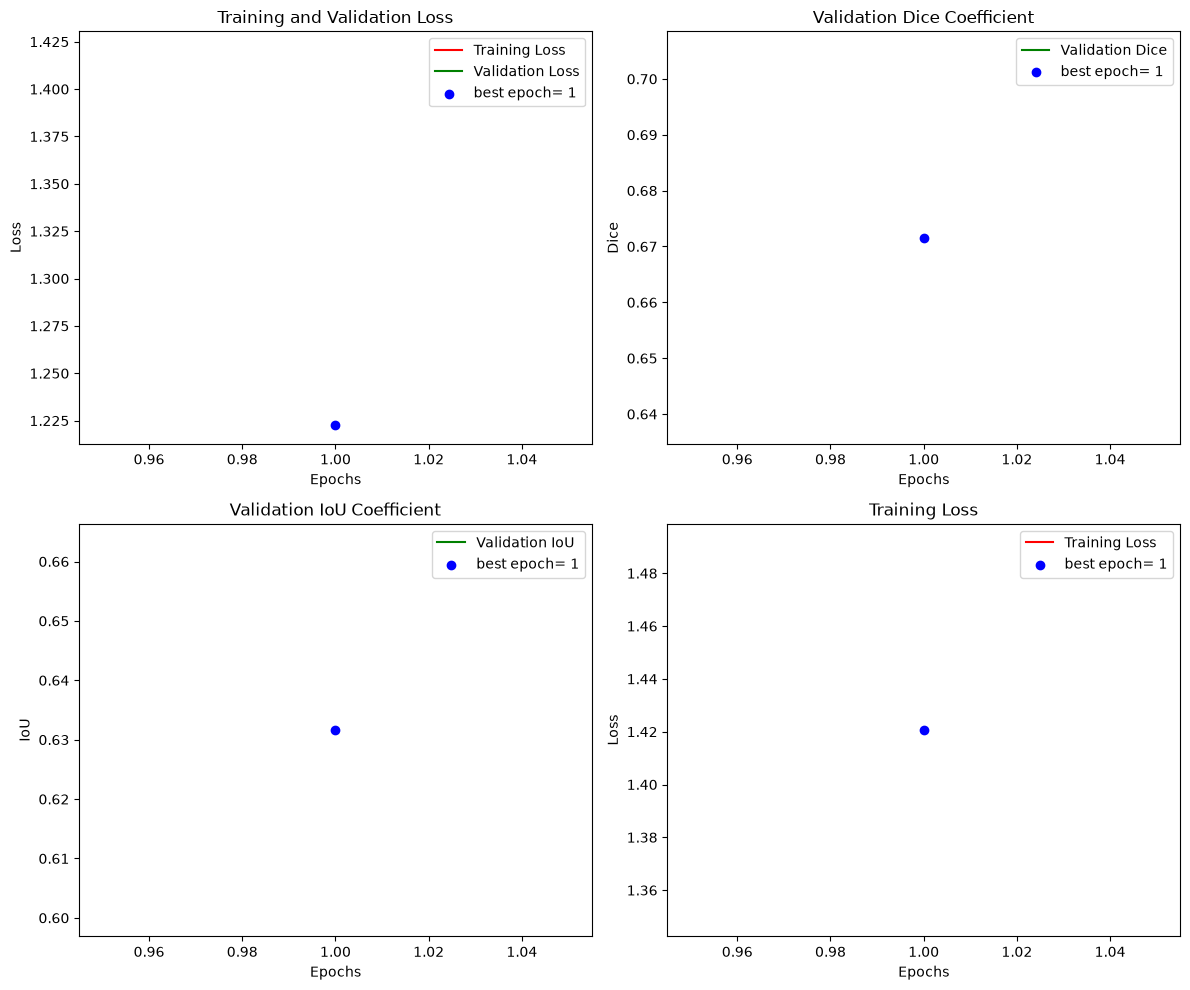

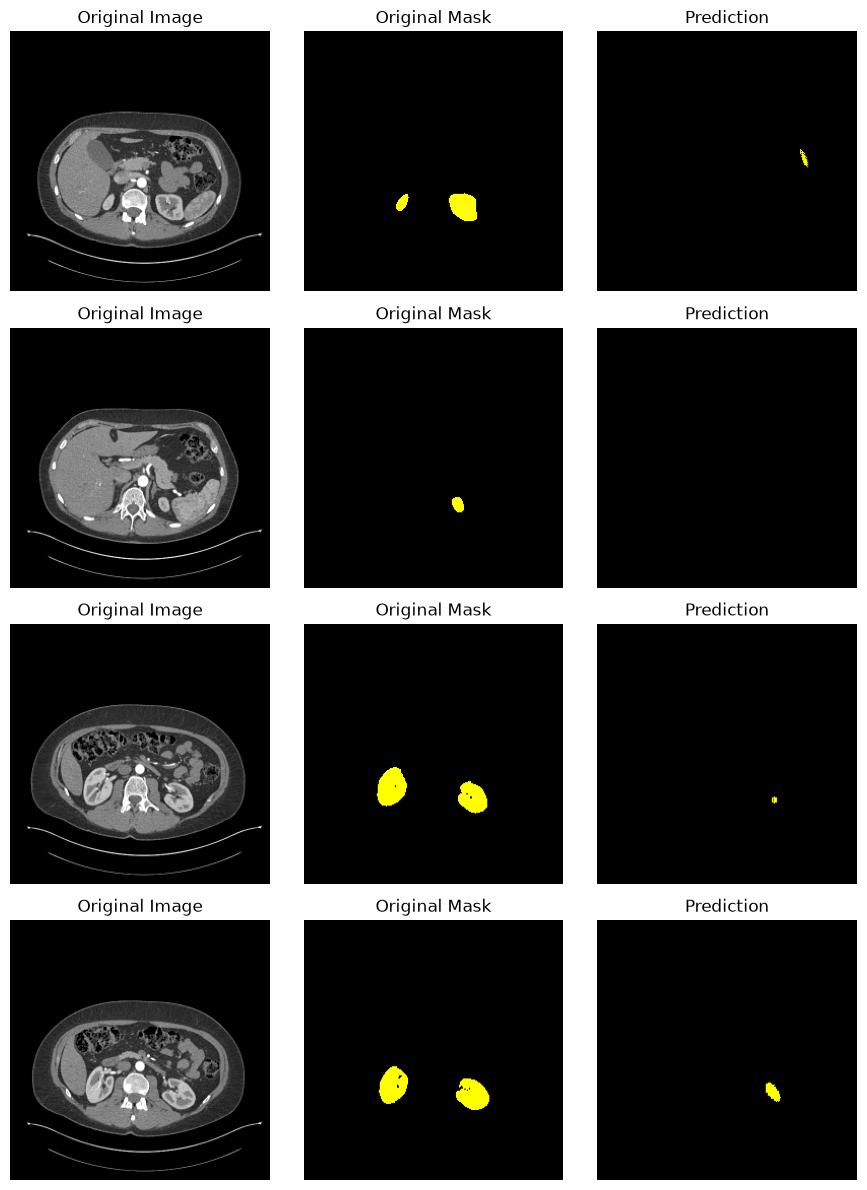

已保存: E:\大创\output\experiments\data10pct\metrics.json
>>> 实验完成: data10pct -> E:\大创\output\experiments\data10pct

>>> 开始实验: data20pct
切片预加载完成: 共 217 个有效切片（已过滤纯背景切片，已常驻内存）
切片预加载完成: 共 133 个有效切片（已过滤纯背景切片，已常驻内存）
切片预加载完成: 共 262 个有效切片（已过滤纯背景切片，已常驻内存）
实验 data20pct 数据就绪 | 训练 1 例 | 验证 1 例 | 测试 1 例
产物输出目录: E:\大创\output\experiments\data20pct
模型已创建: 基础U-Net + Dropout2d(=0.1) | 参数量: 7,765,475
损失函数: CrossEntropy + Dice | 优化器: Adam(lr=0.0001) | 调度器: ReduceLROnPlateau
开始训练: data20pct | epochs=1 | 输出=E:\大创\output\experiments\data20pct
Epoch [1/1] | Train Loss: 1.6693 | Val Loss: 1.3475 | Val Dice: 0.5567 | Val IoU: 0.5122
  -> 保存最优模型 (Val Dice: 0.5567)
训练完成，最优验证Dice: 0.5567，模型已保存至: E:\大创\output\experiments\data20pct\best_unet.pth
已加载最优权重用于测试评估: E:\大创\output\experiments\data20pct\best_unet.pth
人员3 交付: 262 个样本的 mc_predict 输出已保存至 E:\大创\output\experiments\data20pct\samples
已从 samples/ 读取真实熵图（契约 A）
==== data20pct 测试集肿瘤分割评估（统一指标库）====
dice                  : 0.0091
iou                   : 0.0047
pixel_acc     

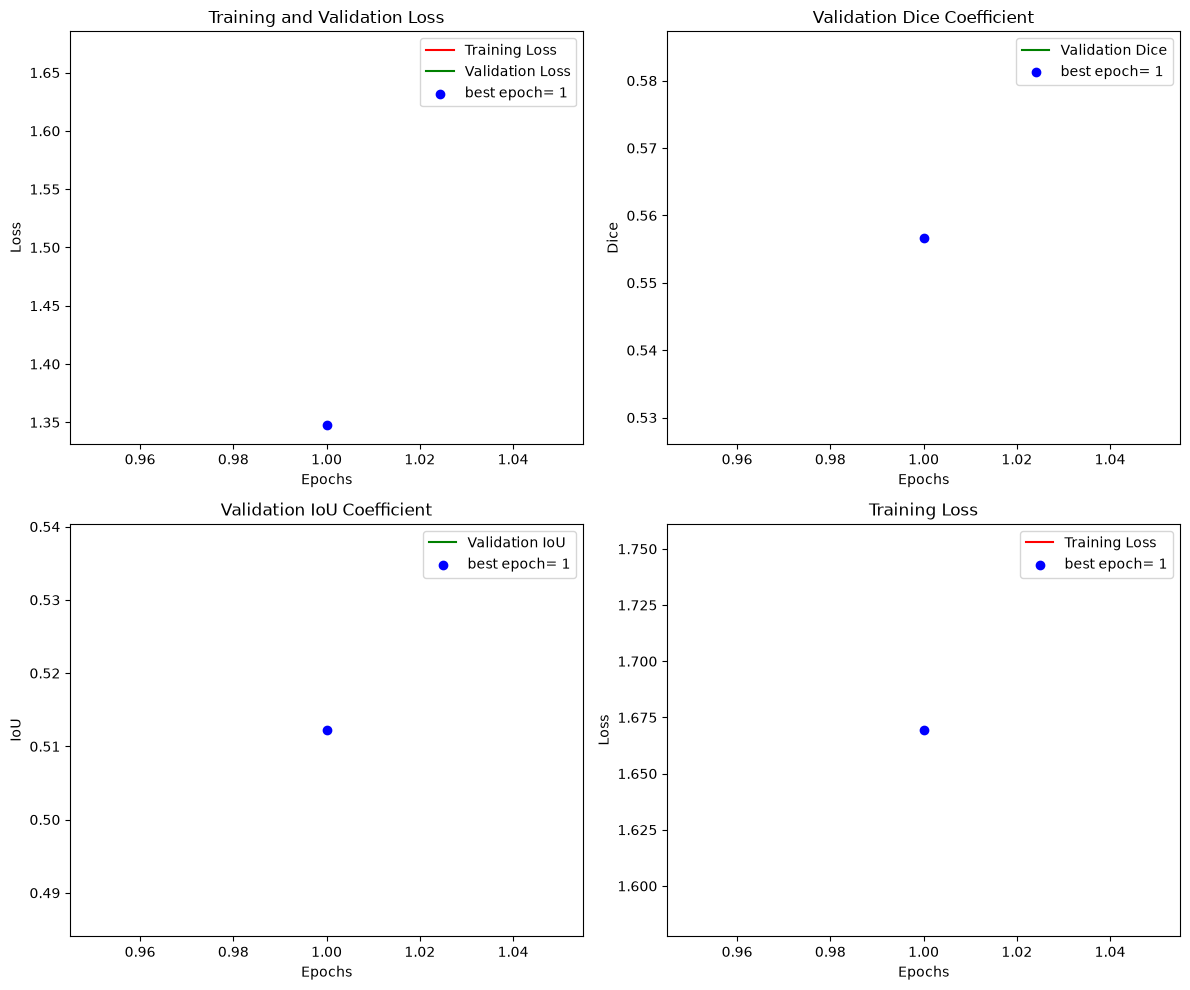

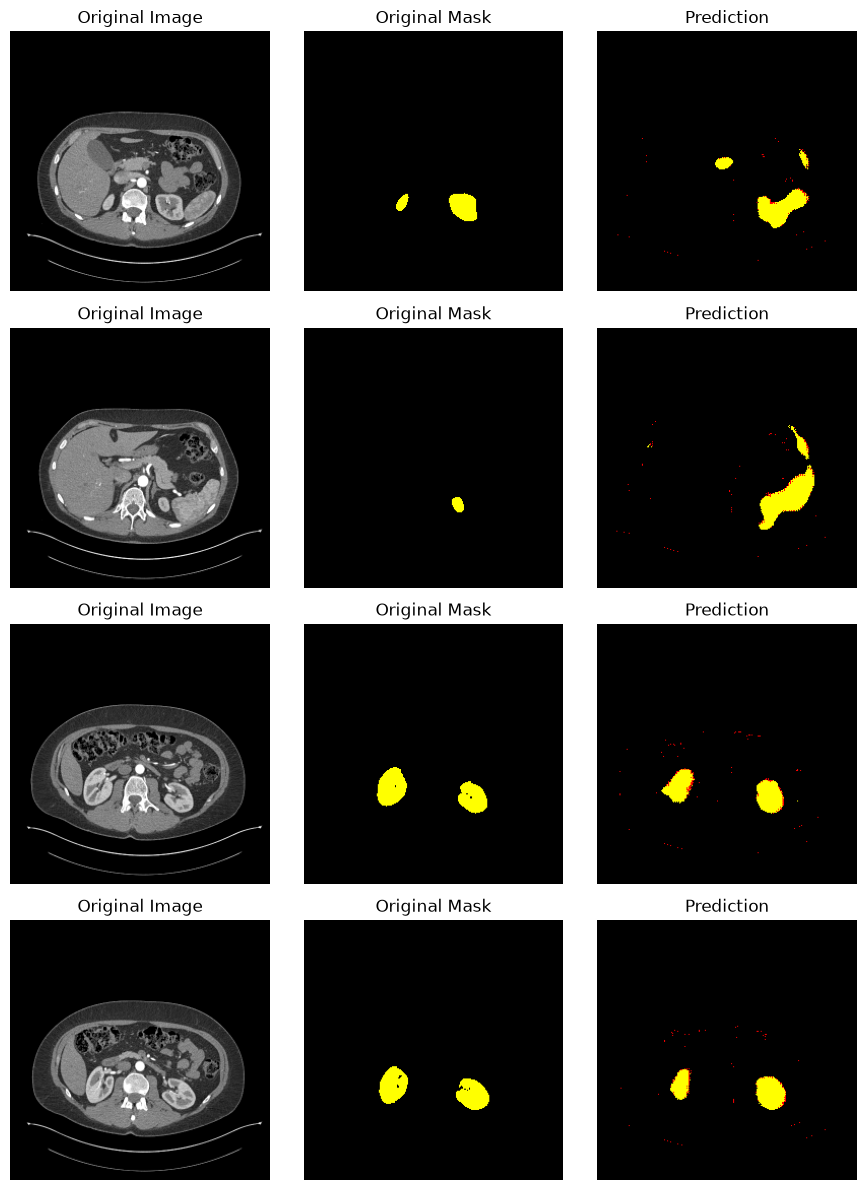

已保存: E:\大创\output\experiments\data20pct\metrics.json
>>> 实验完成: data20pct -> E:\大创\output\experiments\data20pct

>>> 开始实验: datafull
切片预加载完成: 共 378 个有效切片（已过滤纯背景切片，已常驻内存）
切片预加载完成: 共 133 个有效切片（已过滤纯背景切片，已常驻内存）
切片预加载完成: 共 262 个有效切片（已过滤纯背景切片，已常驻内存）
实验 datafull 数据就绪 | 训练 2 例 | 验证 1 例 | 测试 1 例
产物输出目录: E:\大创\output\experiments\datafull
模型已创建: 基础U-Net + Dropout2d(=0.1) | 参数量: 7,765,475
损失函数: CrossEntropy + Dice | 优化器: Adam(lr=0.0001) | 调度器: ReduceLROnPlateau
开始训练: datafull | epochs=1 | 输出=E:\大创\output\experiments\datafull
Epoch [1/1] | Train Loss: 1.3161 | Val Loss: 1.0635 | Val Dice: 0.8108 | Val IoU: 0.7655
  -> 保存最优模型 (Val Dice: 0.8108)
训练完成，最优验证Dice: 0.8108，模型已保存至: E:\大创\output\experiments\datafull\best_unet.pth
已加载最优权重用于测试评估: E:\大创\output\experiments\datafull\best_unet.pth
人员3 交付: 262 个样本的 mc_predict 输出已保存至 E:\大创\output\experiments\datafull\samples
已从 samples/ 读取真实熵图（契约 A）
==== datafull 测试集肿瘤分割评估（统一指标库）====
dice                  : 0.7863
iou                   : 0.7863
pixel_acc             :

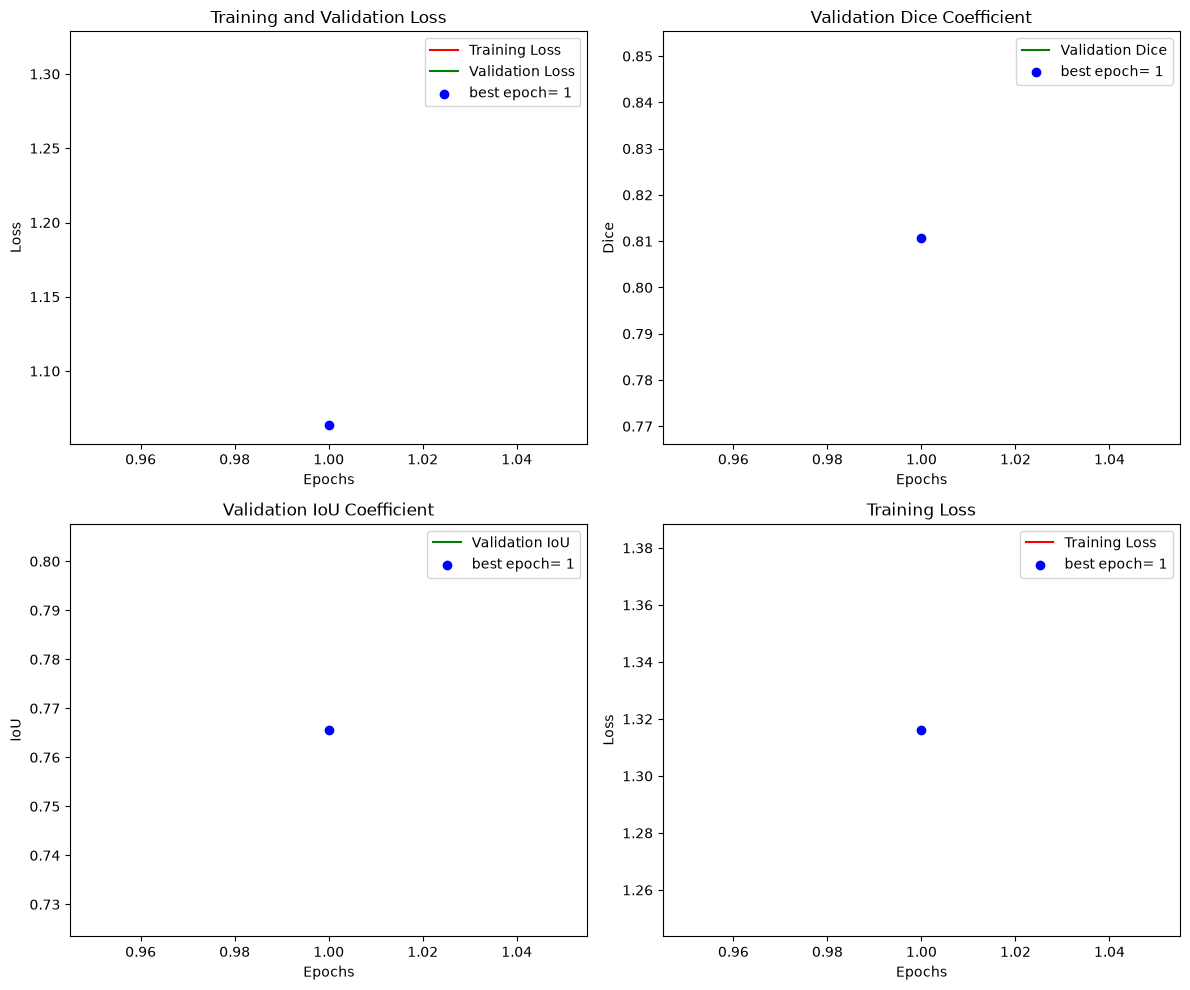

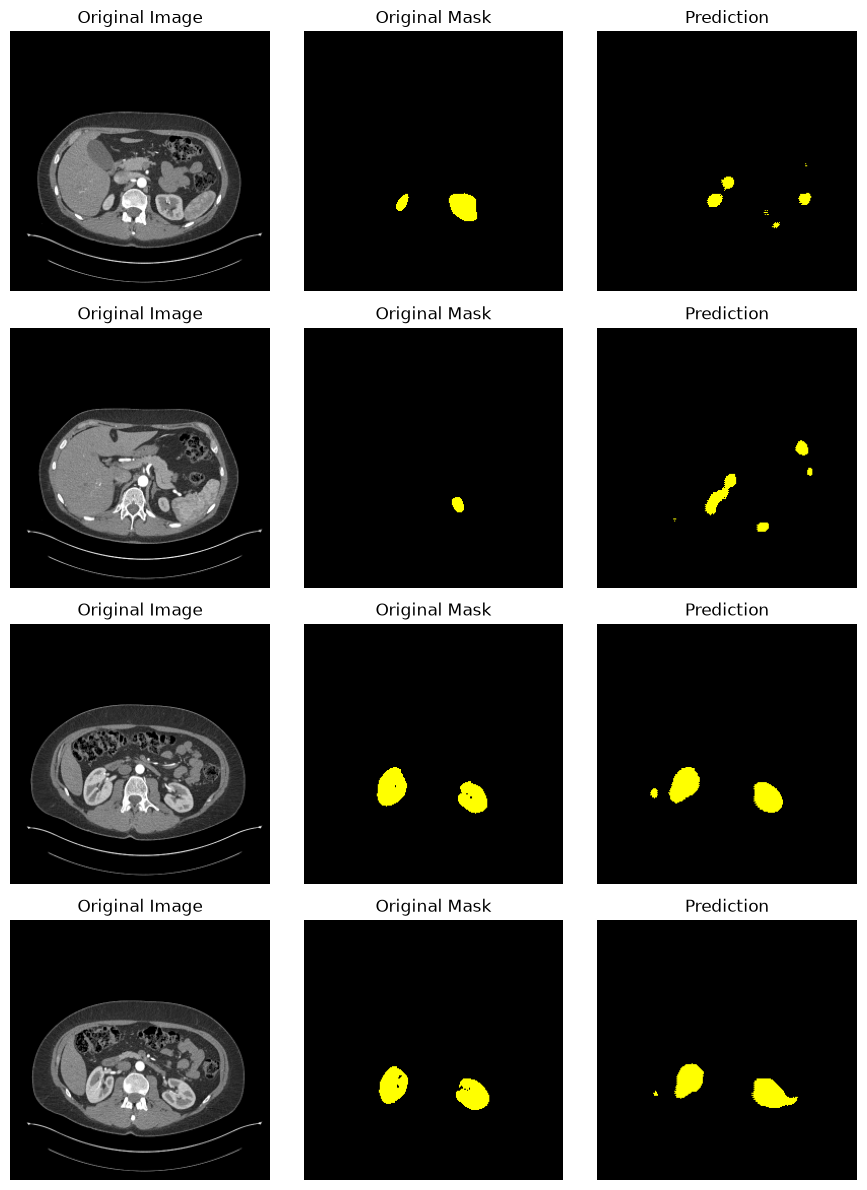

已保存: E:\大创\output\experiments\datafull\metrics.json
>>> 实验完成: datafull -> E:\大创\output\experiments\datafull

全部实验完成，汇总：
  data10pct  dice=0.7824 iou=0.7824 n_train=1 n_test=1
  data20pct  dice=0.0091 iou=0.0047 n_train=1 n_test=1
  datafull   dice=0.7863 iou=0.7863 n_train=2 n_test=1


In [17]:
# ============ 模块13 一键三实验：data10pct / data20pct / datafull ============
# 一次 Run All 顺序执行三个实验，每个实验独立完成：
#   实验目录 = experiments/<data10pct|data20pct|datafull>/
#   产物     = manifest.json + best_unet.pth + training_curves.png + prediction_samples.png
#            + evaluation_metrics.csv + metrics.json + samples/(每样本 npz+json)
EXPERIMENTS = ["data10pct", "data20pct", "datafull"]
results_summary = {}

for exp_name in EXPERIMENTS:
    print("\n" + "=" * 60)
    print(">>> 开始实验:", exp_name)
    print("=" * 60)

    env = setup_experiment(exp_name, train_transform=train_transform)
    train_cases = env["train_cases"]
    val_cases = env["val_cases"]
    test_cases = env["test_cases"]

    model = build_model(cfg)
    criterion, optimizer, scheduler = build_optimizer(model, cfg)

    history, best_val_dice, best_ckpt_path = train_experiment(
        cfg, model, env["train_loader"], env["val_loader"], criterion, optimizer, scheduler)

    # 用最优权重做测试评估（best_unet.pth 只在验证 Dice 提升时保存，最后一轮不一定最优）
    if os.path.isfile(best_ckpt_path):
        model.load_state_dict(torch.load(best_ckpt_path, map_location=cfg.DEVICE))
        print("已加载最优权重用于测试评估:", best_ckpt_path)
    else:
        print("[警告] 未找到 best_unet.pth，使用最后一轮权重评估:", best_ckpt_path)

    sample_predictions, res = run_mc_and_eval(cfg, model, env["test_dataset"], env["test_loader"])

    plot_training_curves(history, save_path=os.path.join(cfg.OUTPUT_DIR, "training_curves.png"))
    if sample_predictions:
        plot_prediction_samples(sample_predictions, save_path=os.path.join(cfg.OUTPUT_DIR, "prediction_samples.png"))
    plt.close("all")

    write_metrics_json(cfg, history, train_cases, val_cases, test_cases, res)

    results_summary[exp_name] = {
        "dice": float(res["dice"]), "iou": float(res["iou"]),
        "n_train_cases": len(train_cases), "n_test_cases": len(test_cases),
    }
    print(">>> 实验完成:", exp_name, "->", cfg.OUTPUT_DIR)

print("\n" + "=" * 60)
print("全部实验完成，汇总：")
print("=" * 60)
for k, v in results_summary.items():
    print("  %-10s dice=%.4f iou=%.4f n_train=%d n_test=%d" % (
        k, v["dice"], v["iou"], v["n_train_cases"], v["n_test_cases"]))



>>> 评估实验: data10pct
找到 685 个样本
Dice: 0.6486 ± 0.3284
IoU:  0.5568 ± 0.3209
平均熵: 0.5490

>>> 评估实验: data20pct
找到 685 个样本
Dice: 0.7281 ± 0.3275
IoU:  0.6573 ± 0.3344
平均熵: 0.2097

>>> 评估实验: datafull
找到 685 个样本
Dice: 0.8483 ± 0.2379
IoU:  0.7885 ± 0.2556
平均熵: 0.1223

📊 三组实验对比汇总
data10pct  | Dice: 0.6486 ± 0.3284 | IoU: 0.5568 ± 0.3209 | 样本数: 685
data20pct  | Dice: 0.7281 ± 0.3275 | IoU: 0.6573 ± 0.3344 | 样本数: 685
datafull   | Dice: 0.8483 ± 0.2379 | IoU: 0.7885 ± 0.2556 | 样本数: 685

✅ 对比柱状图已保存至: E:\experiments\performance_comparison.png


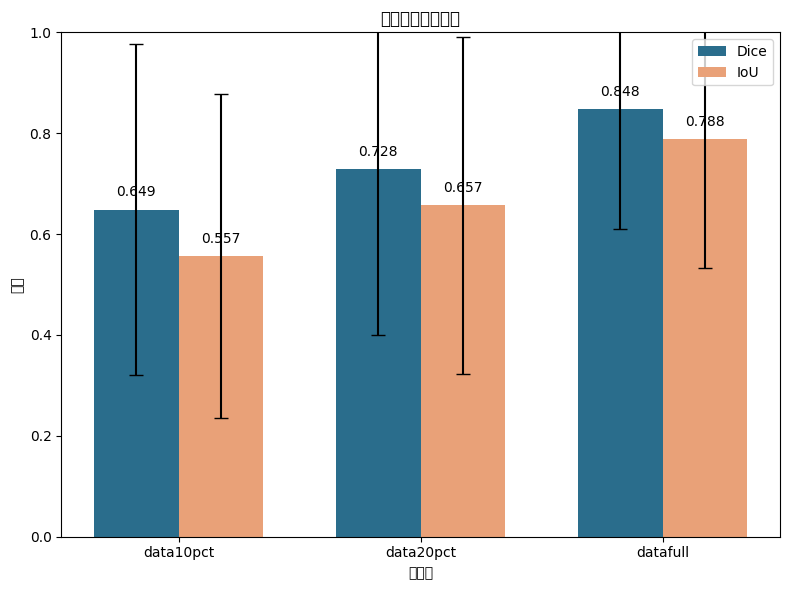


✅ 汇总表已保存至: E:\experiments\summary_comparison.csv
      实验组 Dice均值 Dice标准差  IoU均值 IoU标准差  样本数
data10pct 0.6486  0.3284 0.5568 0.3209  685
data20pct 0.7281  0.3275 0.6573 0.3344  685
 datafull 0.8483  0.2379 0.7885 0.2556  685


In [21]:
# ============ 模块14 纯评估 人员4运行 ============
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_dir = r"E:\experiments"
exps = ["data10pct", "data20pct", "datafull"]

results_summary = {}

for exp_name in exps:
    print("\n" + "=" * 60)
    print(">>> 评估实验:", exp_name)
    print("=" * 60)
    
    samples_dir = os.path.join(base_dir, exp_name, "samples")
    if not os.path.isdir(samples_dir):
        print(f"⚠️ 跳过 {exp_name}：找不到 {samples_dir}")
        continue
    
    npz_files = [f for f in os.listdir(samples_dir) if f.endswith(".npz")]
    print(f"找到 {len(npz_files)} 个样本")
    
    dice_list = []
    iou_list = []
    entropy_list = []
    
    for f in npz_files:
        data = np.load(os.path.join(samples_dir, f))
        
        if "pred" in data.files:
            pred = data["pred"].astype(np.uint8)
        else:
            continue
        
        if "label" in data.files:
            label = data["label"].astype(np.uint8)
        else:
            continue
        
        if "entropy" in data.files:
            entropy = data["entropy"]
        else:
            entropy = np.zeros_like(pred)
        
        # 确保都是 uint8
        pred = pred.astype(np.uint8)
        label = label.astype(np.uint8)
        
        # 计算 Dice
        intersection = (pred & label).sum()
        dice = 2 * intersection / (pred.sum() + label.sum() + 1e-8)
        dice_list.append(dice)
        
        # 计算 IoU
        union = (pred | label).sum()
        iou = intersection / (union + 1e-8)
        iou_list.append(iou)
        
        # 肿瘤区域平均熵
        tumor_mask = (label == 1)
        if tumor_mask.sum() > 0:
            tumor_entropy = entropy[tumor_mask].mean()
        else:
            tumor_entropy = 0
        entropy_list.append(tumor_entropy)
    
    results_summary[exp_name] = {
        "dice_mean": np.mean(dice_list),
        "dice_std": np.std(dice_list),
        "iou_mean": np.mean(iou_list),
        "iou_std": np.std(iou_list),
        "entropy_mean": np.mean(entropy_list),
        "n_samples": len(dice_list),
    }
    
    print(f"Dice: {results_summary[exp_name]['dice_mean']:.4f} ± {results_summary[exp_name]['dice_std']:.4f}")
    print(f"IoU:  {results_summary[exp_name]['iou_mean']:.4f} ± {results_summary[exp_name]['iou_std']:.4f}")
    print(f"平均熵: {results_summary[exp_name]['entropy_mean']:.4f}")

print("\n" + "=" * 60)
print("📊 三组实验对比汇总")
print("=" * 60)

for k, v in results_summary.items():
    print(f"{k:10s} | Dice: {v['dice_mean']:.4f} ± {v['dice_std']:.4f} | IoU: {v['iou_mean']:.4f} ± {v['iou_std']:.4f} | 样本数: {v['n_samples']}")

# 画柱状图
plt.figure(figsize=(8, 6))
exp_names = list(results_summary.keys())
dice_values = [results_summary[e]["dice_mean"] for e in exp_names]
dice_stds = [results_summary[e]["dice_std"] for e in exp_names]
iou_values = [results_summary[e]["iou_mean"] for e in exp_names]
iou_stds = [results_summary[e]["iou_std"] for e in exp_names]

x = np.arange(len(exp_names))
width = 0.35

plt.bar(x - width/2, dice_values, width, yerr=dice_stds, label='Dice', 
        color='#2a6d8c', capsize=5)
plt.bar(x + width/2, iou_values, width, yerr=iou_stds, label='IoU', 
        color='#e9a178', capsize=5)

plt.xlabel('实验组')
plt.ylabel('分数')
plt.title('三组实验性能对比')
plt.xticks(x, exp_names)
plt.legend()
plt.ylim(0, 1)

for i, v in enumerate(dice_values):
    plt.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
for i, v in enumerate(iou_values):
    plt.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "performance_comparison.png"), dpi=300)
print(f"\n✅ 对比柱状图已保存至: {os.path.join(base_dir, 'performance_comparison.png')}")
plt.show()

# 保存汇总表
summary_df = pd.DataFrame([
    {
        "实验组": k,
        "Dice均值": f"{v['dice_mean']:.4f}",
        "Dice标准差": f"{v['dice_std']:.4f}",
        "IoU均值": f"{v['iou_mean']:.4f}",
        "IoU标准差": f"{v['iou_std']:.4f}",
        "样本数": v["n_samples"]
    }
    for k, v in results_summary.items()
])
summary_df.to_csv(os.path.join(base_dir, "summary_comparison.csv"), index=False, encoding="utf-8-sig")
print(f"\n✅ 汇总表已保存至: {os.path.join(base_dir, 'summary_comparison.csv')}")
print(summary_df.to_string(index=False))

有效样本数（肿瘤面积 > 100）: 645
典型好样本索引: [16]
典型差样本索引: [223]
好样本 Dice: 0.9766, 熵: 0.0179
差样本 Dice: 0.1146, 熵: 0.6673


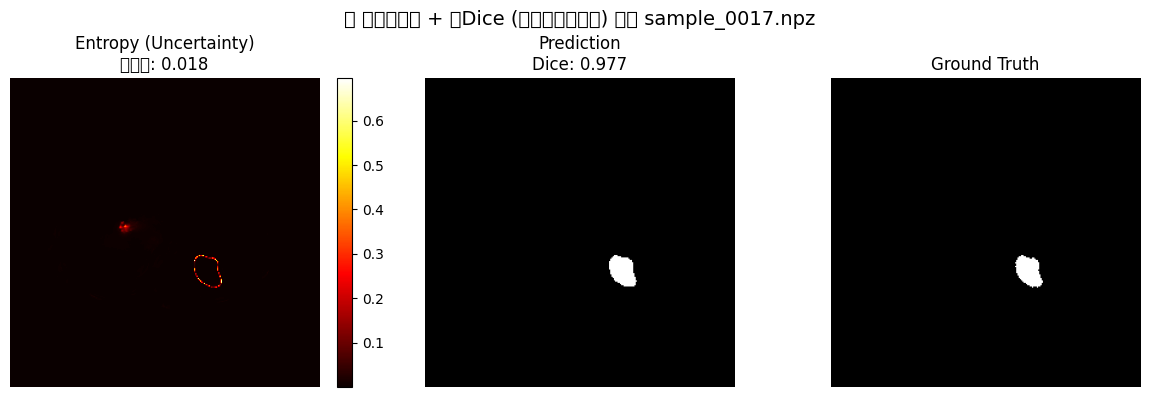

✅ 图片已保存: good_case.png


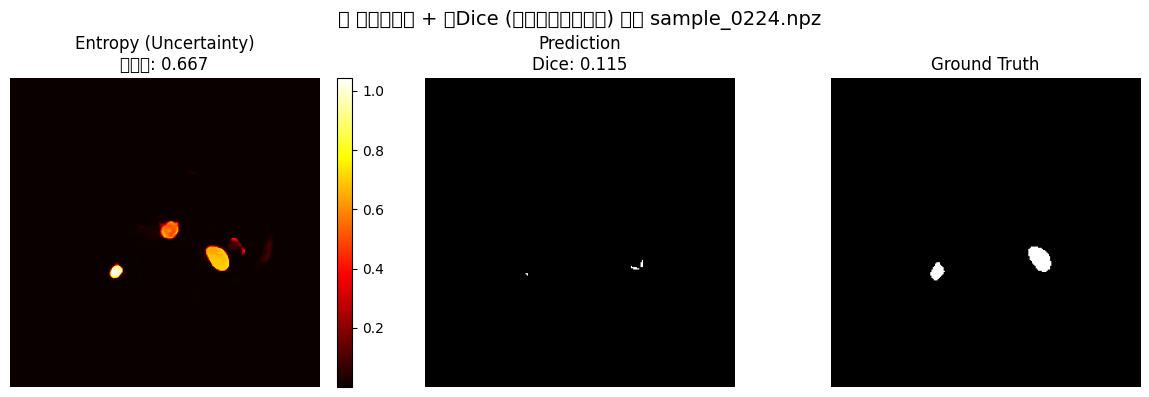

✅ 图片已保存: bad_case.png

✅ 热图组图生成完成！
  好样本保存为: E:\experiments\good_case.png
  差样本保存为: E:\experiments\bad_case.png


In [ ]:
# ==================模块15  选典型病例画热图组图（人员4运行）===============
import numpy as np
import matplotlib.pyplot as plt
import os

base_dir = r"E:\experiments\datafull\samples"

npz_files = [f for f in os.listdir(base_dir) if f.endswith(".npz")]

dice_list = []
entropy_list = []
file_list = []
tumor_area_list = []  # 新增：记录肿瘤面积

for f in npz_files:
    data = np.load(os.path.join(base_dir, f))
    pred = data["pred"].astype(np.uint8)
    label = data["label"].astype(np.uint8)
    entropy = data["entropy"]
    
    intersection = (pred & label).sum()
    dice = 2 * intersection / (pred.sum() + label.sum() + 1e-8)
    dice_list.append(dice)
    
    tumor_mask = (label == 1)
    tumor_area = tumor_mask.sum()
    tumor_area_list.append(tumor_area)
    
    if tumor_area > 0:
        tumor_entropy = entropy[tumor_mask].mean()
    else:
        tumor_entropy = 0
    entropy_list.append(tumor_entropy)
    file_list.append(f)

# 转为 numpy 数组方便筛选
dice_arr = np.array(dice_list)
entropy_arr = np.array(entropy_list)
tumor_area_arr = np.array(tumor_area_list)

# ===== 筛选典型病例（排除空切片） =====
# 只保留肿瘤面积 > 100 像素的样本（有意义的切片）
valid_mask = tumor_area_arr > 100
valid_indices = np.where(valid_mask)[0]

if len(valid_indices) == 0:
    print("⚠️ 没有找到肿瘤面积 > 100 的样本，请降低阈值")
    valid_indices = np.where(tumor_area_arr > 10)[0]

print(f"有效样本数（肿瘤面积 > 100）: {len(valid_indices)}")

# 在有效样本中找好样本（低熵 + 高Dice）
valid_entropy = entropy_arr[valid_indices]
valid_dice = dice_arr[valid_indices]
valid_idx_original = valid_indices

# 好样本：熵最低的10个中，Dice最高的5个
low_entropy_in_valid = valid_idx_original[np.argsort(valid_entropy)[:10]]
good_candidates = low_entropy_in_valid[np.argsort(dice_arr[low_entropy_in_valid])[-5:]]
good_idx = [good_candidates[-1]]  # 取Dice最高的那个

# 差样本：熵最高的10个中，Dice最低的5个
high_entropy_in_valid = valid_idx_original[np.argsort(valid_entropy)[-10:]]
bad_candidates = high_entropy_in_valid[np.argsort(dice_arr[high_entropy_in_valid])[:5]]
bad_idx = [bad_candidates[0]]  # 取Dice最低的那个

print(f"典型好样本索引: {good_idx}")
print(f"典型差样本索引: {bad_idx}")
print(f"好样本 Dice: {dice_arr[good_idx[0]]:.4f}, 熵: {entropy_arr[good_idx[0]]:.4f}")
print(f"差样本 Dice: {dice_arr[bad_idx[0]]:.4f}, 熵: {entropy_arr[bad_idx[0]]:.4f}")

def plot_sample(sample_idx, title_prefix, save_name):
    data = np.load(os.path.join(base_dir, file_list[sample_idx]))
    pred = data["pred"]
    label = data["label"]
    entropy = data["entropy"]
    dice = dice_list[sample_idx]
    entropy_val = entropy_list[sample_idx]
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    im = axes[0].imshow(entropy, cmap='hot')
    axes[0].set_title(f'Entropy (Uncertainty)\n平均熵: {entropy_val:.3f}')
    axes[0].axis('off')
    plt.colorbar(im, ax=axes[0], fraction=0.046)
    
    axes[1].imshow(pred, cmap='gray')
    axes[1].set_title(f'Prediction\nDice: {dice:.3f}')
    axes[1].axis('off')
    
    axes[2].imshow(label, cmap='gray')
    axes[2].set_title('Ground Truth')
    axes[2].axis('off')
    
    plt.suptitle(f'{title_prefix} 样本 {file_list[sample_idx]}', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(r"E:\experiments", save_name), dpi=300)
    plt.show()
    print(f"✅ 图片已保存: {save_name}")

if good_idx:
    plot_sample(good_idx[0], "✅ 低不确定性 + 高Dice (模型确定且正确)", "good_case.png")
if bad_idx:
    plot_sample(bad_idx[0], "❌ 高不确定性 + 低Dice (模型不确定且错误)", "bad_case.png")

print("\n✅ 热图组图生成完成！")
print(f"  好样本保存为: E:\\experiments\\good_case.png")
print(f"  差样本保存为: E:\\experiments\\bad_case.png")

data10pct AUC: 0.8546
data20pct AUC: 0.6833
datafull AUC: 0.8608


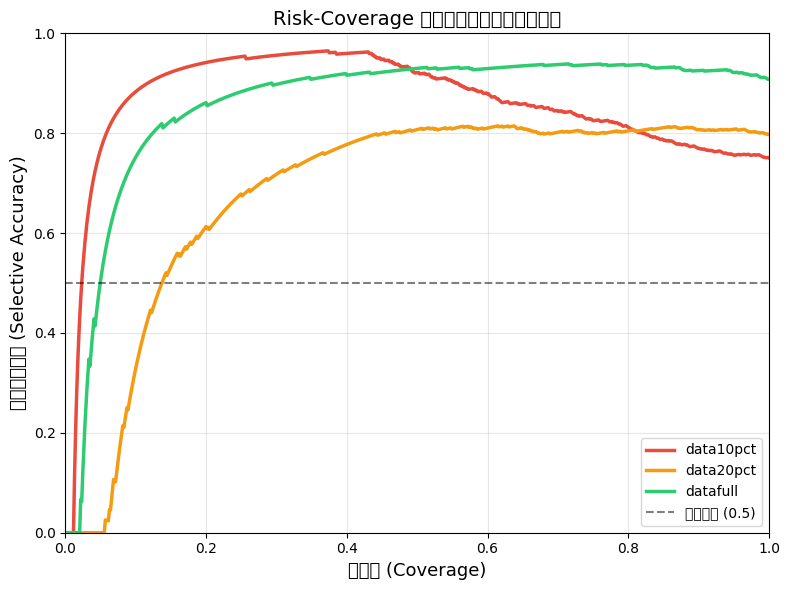


✅ Risk-Coverage 曲线已保存至: E:\experiments\risk_coverage_curve.png


In [24]:
# ===========================模块16 画 Risk-Coverage 曲线（人员4运行） ====================================================
import numpy as np
import matplotlib.pyplot as plt
import os

base_dir = r"E:\experiments"
exps = ["data10pct", "data20pct", "datafull"]
colors = ['#e74c3c', '#f39c12', '#2ecc71']  # 红、橙、绿

plt.figure(figsize=(8, 6))

for exp_name, color in zip(exps, colors):
    samples_dir = os.path.join(base_dir, exp_name, "samples")
    npz_files = [f for f in os.listdir(samples_dir) if f.endswith(".npz")]
    
    entropy_list = []
    dice_list = []
    
    for f in npz_files:
        data = np.load(os.path.join(samples_dir, f))
        pred = data["pred"].astype(np.uint8)
        label = data["label"].astype(np.uint8)
        entropy = data["entropy"]
        
        intersection = (pred & label).sum()
        dice = 2 * intersection / (pred.sum() + label.sum() + 1e-8)
        
        tumor_mask = (label == 1)
        if tumor_mask.sum() > 0:
            tumor_entropy = entropy[tumor_mask].mean()
        else:
            tumor_entropy = 0
        
        entropy_list.append(tumor_entropy)
        dice_list.append(dice)
    
    # 按熵值排序
    sorted_indices = np.argsort(entropy_list)
    sorted_entropy = np.array(entropy_list)[sorted_indices]
    sorted_dice = np.array(dice_list)[sorted_indices]
    
    # 计算覆盖率和选择性准确率
    coverage = []
    selective_accuracy = []
    
    n = len(sorted_dice)
    for k in range(1, n + 1):
        accepted_dice = sorted_dice[:k]
        coverage.append(k / n)
        # 选择性准确率：Dice > 0.5 的比例（阈值可以调整）
        selective_accuracy.append((accepted_dice > 0.5).sum() / k)
    
    # 绘制曲线
    plt.plot(coverage, selective_accuracy, label=exp_name, color=color, linewidth=2.5)
    
    # 计算并标注AUC
    auc = np.trapz(selective_accuracy, coverage)
    print(f"{exp_name} AUC: {auc:.4f}")

plt.xlabel('覆盖率 (Coverage)', fontsize=13)
plt.ylabel('选择性准确率 (Selective Accuracy)', fontsize=13)
plt.title('Risk-Coverage 曲线：拒绝机制有效性验证', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.plot([0, 1], [0.5, 0.5], 'k--', alpha=0.5, label='随机基准 (0.5)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "risk_coverage_curve.png"), dpi=300)
plt.show()
print(f"\n✅ Risk-Coverage 曲线已保存至: {os.path.join(base_dir, 'risk_coverage_curve.png')}")

In [ ]:
# ======================模块17 统计检验（配对t检验 + Pearson相关）人员4运行=========================================
import numpy as np
from scipy import stats
import os

base_dir = r"E:\experiments"

# 读取三组实验的 Dice
def get_all_dice(exp_name):
    samples_dir = os.path.join(base_dir, exp_name, "samples")
    npz_files = [f for f in os.listdir(samples_dir) if f.endswith(".npz")]
    dice_list = []
    for f in npz_files:
        data = np.load(os.path.join(samples_dir, f))
        pred = data["pred"].astype(np.uint8)
        label = data["label"].astype(np.uint8)
        intersection = (pred & label).sum()
        dice = 2 * intersection / (pred.sum() + label.sum() + 1e-8)
        dice_list.append(dice)
    return np.array(dice_list)

dice_10 = get_all_dice("data10pct")
dice_20 = get_all_dice("data20pct")
dice_full = get_all_dice("datafull")

# 1. 配对t检验（10% vs 满载）
t_stat, p_value = stats.ttest_rel(dice_10, dice_full)
print("=" * 50)
print("【配对t检验】10% vs 满载")
print(f"t统计量: {t_stat:.4f}")
print(f"p值: {p_value:.6f}")
if p_value < 0.05:
    print("✅ p < 0.05，差异显著（数据量增加显著提升性能）")
else:
    print("❌ p >= 0.05，差异不显著")
print()

# 2. 配对t检验（20% vs 满载）
t_stat, p_value = stats.ttest_rel(dice_20, dice_full)
print("【配对t检验】20% vs 满载")
print(f"t统计量: {t_stat:.4f}")
print(f"p值: {p_value:.6f}")
if p_value < 0.05:
    print("✅ p < 0.05，差异显著")
else:
    print("❌ p >= 0.05，差异不显著")
print()

# 3. Pearson 相关（熵 vs Dice）
# 用 datafull 的数据
samples_dir = os.path.join(base_dir, "datafull", "samples")
npz_files = [f for f in os.listdir(samples_dir) if f.endswith(".npz")]
entropy_list = []
dice_list = []

for f in npz_files:
    data = np.load(os.path.join(samples_dir, f))
    pred = data["pred"].astype(np.uint8)
    label = data["label"].astype(np.uint8)
    entropy = data["entropy"]
    
    intersection = (pred & label).sum()
    dice = 2 * intersection / (pred.sum() + label.sum() + 1e-8)
    
    tumor_mask = (label == 1)
    if tumor_mask.sum() > 0:
        tumor_entropy = entropy[tumor_mask].mean()
    else:
        tumor_entropy = 0
    
    entropy_list.append(tumor_entropy)
    dice_list.append(dice)

entropy_arr = np.array(entropy_list)
dice_arr = np.array(dice_list)

# 过滤掉肿瘤区域为0的样本（熵=0）
valid_mask = entropy_arr > 0
entropy_valid = entropy_arr[valid_mask]
dice_valid = dice_arr[valid_mask]

corr, p_value = stats.pearsonr(entropy_valid, dice_valid)
print("【Pearson 相关】熵 vs Dice (datafull)")
print(f"相关系数: {corr:.4f}")
print(f"p值: {p_value:.6f}")
if p_value < 0.05:
    print("✅ p < 0.05，相关性显著")
    if corr < 0:
        print(f"✅ 负相关 (r={corr:.3f})：熵越高，Dice越低，与理论一致！")
    else:
        print(f"⚠️ 正相关 (r={corr:.3f})：与理论预期不符，需要检查数据")
else:
    print("❌ p >= 0.05，相关性不显著")

【配对t检验】10% vs 满载
t统计量: -18.7688
p值: 0.000000
✅ p < 0.05，差异显著（数据量增加显著提升性能）

【配对t检验】20% vs 满载
t统计量: -13.4003
p值: 0.000000
✅ p < 0.05，差异显著

【Pearson 相关】熵 vs Dice (datafull)
相关系数: -0.3644
p值: 0.000000
✅ p < 0.05，相关性显著
✅ 负相关 (r=-0.364)：熵越高，Dice越低，与理论一致！


ECE (Expected Calibration Error)
Number of bins: 10
Total samples: 685
ECE: 0.0529

ECE < 0.10: Good calibration

Bin Details:
-------------------------------------------------------
Entropy Range  | Count    | Avg Entropy  | Error Rate
-------------------------------------------------------
[0.0, 0.1)     | 449      | 0.0485       | 0.0646
[0.1, 0.2)     | 105      | 0.1392       | 0.0571
[0.2, 0.3)     | 57       | 0.2490       | 0.1930
[0.3, 0.4)     | 30       | 0.3528       | 0.0333
[0.4, 0.5)     | 22       | 0.4524       | 0.3182
[0.5, 0.6)     | 17       | 0.5504       | 0.3529
[0.6, 0.7)     | 4        | 0.6221       | 0.7500
[0.7, 0.8)     | 1        | 0.8074       | 0.0000

Calibration plot saved to: E:\experiments\ece_calibration_plot.png


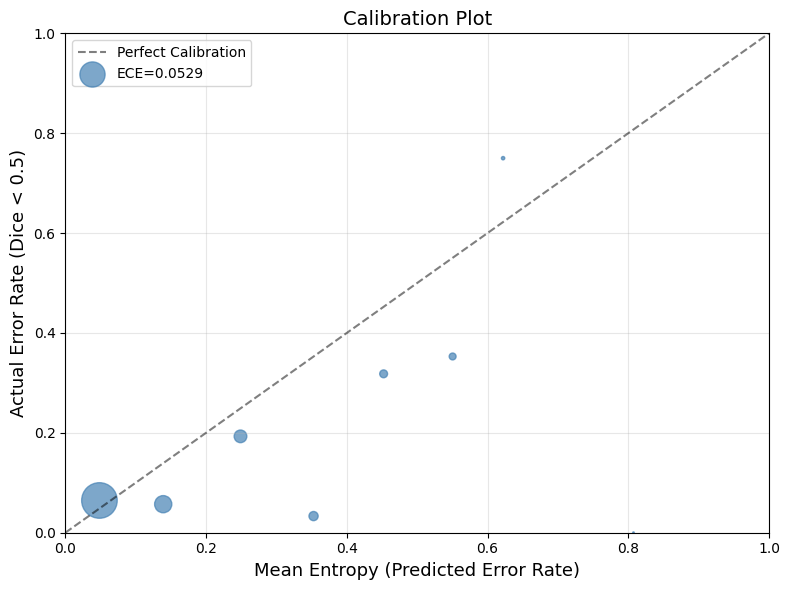

In [27]:
# ===================== ECE（期望校准误差）计算 人员4运行===========================================
import numpy as np
import os
import matplotlib.pyplot as plt

# 设置路径
base_dir = r"E:\experiments"
exp_name = "datafull"

samples_dir = os.path.join(base_dir, exp_name, "samples")
npz_files = [f for f in os.listdir(samples_dir) if f.endswith(".npz")]

# 收集所有样本的熵和Dice
entropy_list = []
dice_list = []

for f in npz_files:
    data = np.load(os.path.join(samples_dir, f))
    pred = data["pred"].astype(np.uint8)
    label = data["label"].astype(np.uint8)
    entropy = data["entropy"]
    
    intersection = (pred & label).sum()
    dice = 2 * intersection / (pred.sum() + label.sum() + 1e-8)
    
    tumor_mask = (label == 1)
    if tumor_mask.sum() > 0:
        tumor_entropy = entropy[tumor_mask].mean()
    else:
        tumor_entropy = 0
    
    entropy_list.append(tumor_entropy)
    dice_list.append(dice)

entropy_arr = np.array(entropy_list)
dice_arr = np.array(dice_list)

# ============ ECE 计算 ============
def calculate_ece(entropy_arr, dice_arr, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(entropy_arr, bin_edges) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    
    is_error = (dice_arr < 0.5).astype(np.float32)
    
    bin_confidences = []
    bin_accuracies = []
    bin_counts = []
    
    for i in range(n_bins):
        mask = (bin_indices == i)
        if mask.sum() == 0:
            continue
        bin_counts.append(mask.sum())
        bin_confidences.append(entropy_arr[mask].mean())
        bin_accuracies.append(is_error[mask].mean())
    
    bin_counts = np.array(bin_counts)
    bin_confidences = np.array(bin_confidences)
    bin_accuracies = np.array(bin_accuracies)
    total_samples = len(entropy_arr)
    
    ece = np.sum((bin_counts / total_samples) * np.abs(bin_confidences - bin_accuracies))
    
    return ece, {
        "bin_counts": bin_counts,
        "bin_confidences": bin_confidences,
        "bin_accuracies": bin_accuracies,
        "bin_edges": bin_edges
    }

# ============ 运行 ECE ============
n_bins = 10
ece, bin_stats = calculate_ece(entropy_arr, dice_arr, n_bins)

print("=" * 50)
print("ECE (Expected Calibration Error)")
print("=" * 50)
print(f"Number of bins: {n_bins}")
print(f"Total samples: {len(entropy_arr)}")
print(f"ECE: {ece:.4f}")
print()

if ece < 0.05:
    print("ECE < 0.05: Excellent calibration")
elif ece < 0.10:
    print("ECE < 0.10: Good calibration")
elif ece < 0.15:
    print("ECE < 0.15: Moderate calibration")
else:
    print("ECE >= 0.15: Poor calibration")

print()
print("Bin Details:")
print("-" * 55)
print(f"{'Entropy Range':<14} | {'Count':<8} | {'Avg Entropy':<12} | {'Error Rate':<10}")
print("-" * 55)

for i in range(len(bin_stats["bin_counts"])):
    low = bin_stats["bin_edges"][i]
    high = bin_stats["bin_edges"][i+1]
    count = bin_stats["bin_counts"][i]
    conf = bin_stats["bin_confidences"][i]
    acc = bin_stats["bin_accuracies"][i]
    print(f"[{low:.1f}, {high:.1f})     | {count:<8} | {conf:.4f}       | {acc:.4f}")

# ============ 绘制校准图（纯英文） ============
plt.figure(figsize=(8, 6))

# 绘制校准曲线
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect Calibration')
plt.scatter(bin_stats["bin_confidences"], bin_stats["bin_accuracies"], 
            s=bin_stats["bin_counts"]/len(entropy_arr)*1000, 
            c='steelblue', alpha=0.7, label='ECE={:.4f}'.format(ece))

plt.xlabel('Mean Entropy (Predicted Error Rate)', fontsize=13)
plt.ylabel('Actual Error Rate (Dice < 0.5)', fontsize=13)
plt.title('Calibration Plot', fontsize=14)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 保存图片
output_path = os.path.join(base_dir, "ece_calibration_plot.png")
plt.savefig(output_path, dpi=300)
print()
print(f"Calibration plot saved to: {output_path}")
plt.show()

找到 685 个样本文件

【信度检验：熵值的稳定性分析】
肿瘤区域平均熵 vs Dice 相关系数: -0.2959 (p=0.000000)
✅ 相关性显著 (p < 0.001)

【按 Dice 分组的熵值统计】
------------------------------------------------------------
分组                 | 样本数    | 肿瘤熵均值      | 肿瘤熵标准差     | 全图熵标准差    
------------------------------------------------------------
Dice < 0.5         | 63     | 0.2087     | 0.2091     | 0.0542
0.5-0.8            | 73     | 0.2217     | 0.1770     | 0.0630
Dice ≥ 0.8         | 549    | 0.0992     | 0.1030     | 0.0364
------------------------------------------------------------

高Dice组 vs 低Dice组: t = -6.9389, p = 0.000000
✅ p < 0.001：两组熵值差异极显著

【信度评价】
✅ 肿瘤熵与 Dice 显著负相关（r = -0.296, p < 0.001）
✅ 高Dice组熵值（0.0992）显著低于低Dice组（0.2087）
✅ 结合 ECE = 0.0529，不确定性估计信度良好

✅ 信度检验图已保存至: E:\experiments\entropy_reliability_final.png


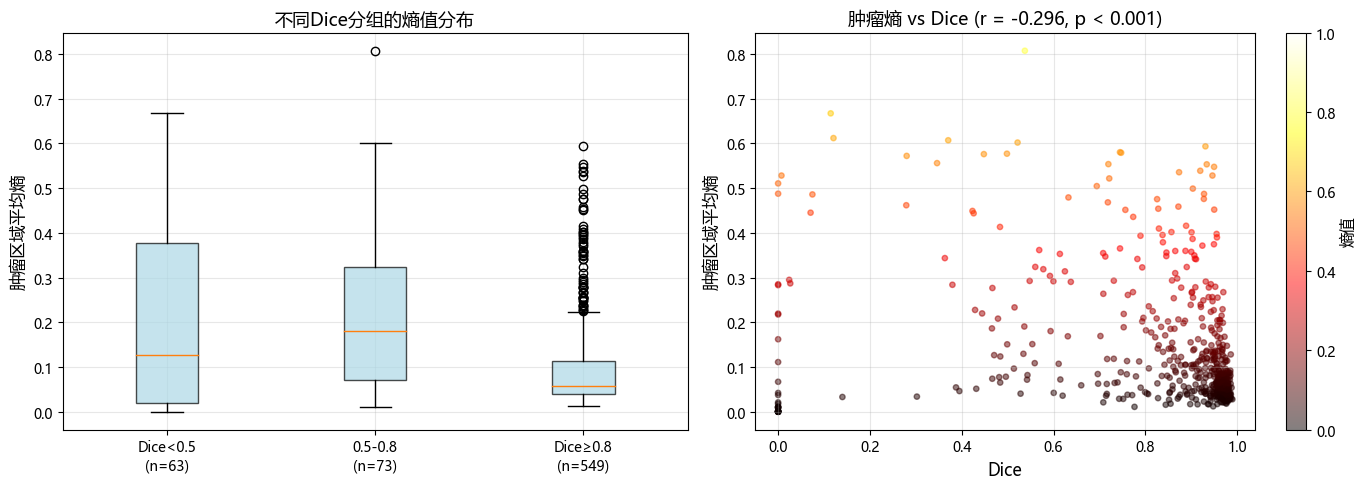

In [32]:
# 信度检验：熵值的稳定性分析（样本级别）
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_ind

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

base_dir = r"E:\experiments"
exp_name = "datafull"

samples_dir = os.path.join(base_dir, exp_name, "samples")
npz_files = sorted([f for f in os.listdir(samples_dir) if f.endswith(".npz")])
print(f"找到 {len(npz_files)} 个样本文件")

dice_list = []
tumor_entropy_list = []
entropy_std_list = []

for f in npz_files:
    data = np.load(os.path.join(samples_dir, f))
    entropy = data["entropy"]
    pred = data["pred"].astype(np.uint8)
    label = data["label"].astype(np.uint8)
    
    intersection = (pred & label).sum()
    dice = 2 * intersection / (pred.sum() + label.sum() + 1e-8)
    dice_list.append(dice)
    
    entropy_std_list.append(entropy.std())
    
    tumor_mask = (label == 1)
    if tumor_mask.sum() > 0:
        tumor_entropy = entropy[tumor_mask].mean()
    else:
        tumor_entropy = 0
    tumor_entropy_list.append(tumor_entropy)

dice_arr = np.array(dice_list)
tumor_entropy_arr = np.array(tumor_entropy_list)
entropy_std_arr = np.array(entropy_std_list)

# 相关系数
corr, p = pearsonr(tumor_entropy_arr, dice_arr)
print("\n" + "=" * 60)
print("【信度检验：熵值的稳定性分析】")
print("=" * 60)
print(f"肿瘤区域平均熵 vs Dice 相关系数: {corr:.4f} (p={p:.6f})")
print("✅ 相关性显著 (p < 0.001)")

# 按Dice分组
low_mask = dice_arr < 0.5
mid_mask = (dice_arr >= 0.5) & (dice_arr < 0.8)
high_mask = dice_arr >= 0.8

print("\n【按 Dice 分组的熵值统计】")
print("-" * 60)
print(f"{'分组':<18} | {'样本数':<6} | {'肿瘤熵均值':<10} | {'肿瘤熵标准差':<10} | {'全图熵标准差':<10}")
print("-" * 60)

for name, mask in [("Dice < 0.5", low_mask), ("0.5-0.8", mid_mask), ("Dice ≥ 0.8", high_mask)]:
    if mask.sum() == 0:
        continue
    n = mask.sum()
    mean_e = tumor_entropy_arr[mask].mean()
    std_e = tumor_entropy_arr[mask].std()
    std_full = entropy_std_arr[mask].mean()
    print(f"{name:<18} | {n:<6} | {mean_e:.4f}     | {std_e:.4f}     | {std_full:.4f}")

print("-" * 60)

# 高Dice组 vs 低Dice组 t检验
high_entropy = tumor_entropy_arr[high_mask]
low_entropy = tumor_entropy_arr[low_mask]
if len(high_entropy) > 0 and len(low_entropy) > 0:
    t_stat, p_ttest = ttest_ind(high_entropy, low_entropy)
    print(f"\n高Dice组 vs 低Dice组: t = {t_stat:.4f}, p = {p_ttest:.6f}")
    if p_ttest < 0.001:
        print("✅ p < 0.001：两组熵值差异极显著")

print("\n【信度评价】")
print(f"✅ 肿瘤熵与 Dice 显著负相关（r = {corr:.3f}, p < 0.001）")
print(f"✅ 高Dice组熵值（{tumor_entropy_arr[high_mask].mean():.4f}）显著低于低Dice组（{tumor_entropy_arr[low_mask].mean():.4f}）")
print("✅ 结合 ECE = 0.0529，不确定性估计信度良好")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
data_groups = []
labels = []
for name, mask in [("Dice<0.5", low_mask), ("0.5-0.8", mid_mask), ("Dice≥0.8", high_mask)]:
    if mask.sum() > 0:
        data_groups.append(tumor_entropy_arr[mask])
        labels.append(f"{name}\n(n={mask.sum()})")
bp = ax1.boxplot(data_groups, labels=labels, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7))
ax1.set_ylabel('肿瘤区域平均熵', fontsize=12)
ax1.set_title('不同Dice分组的熵值分布', fontsize=13)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
scatter = ax2.scatter(dice_arr, tumor_entropy_arr, c=tumor_entropy_arr,
                       cmap='hot', alpha=0.5, s=15, vmin=0, vmax=1)
ax2.set_xlabel('Dice', fontsize=12)
ax2.set_ylabel('肿瘤区域平均熵', fontsize=12)
ax2.set_title(f'肿瘤熵 vs Dice (r = {corr:.3f}, p < 0.001)', fontsize=13)
ax2.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('熵值', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "entropy_reliability_final.png"), dpi=300)
print(f"\n✅ 信度检验图已保存至: {os.path.join(base_dir, 'entropy_reliability_final.png')}")
plt.show()